# Cointegration Pairs Trading - {SYMBOL1}/{SYMBOL2} Analysis

This notebook implements a cointegration-based pairs trading strategy for {SYMBOL1} and {SYMBOL2} using the Johansen test to determine optimal hedge ratios.

**Objective**: Achieve Sharpe Ratio of 1.0 bwtween 2018-2024 using statistical arbitrage

**Methodology**:
1. Use Johansen cointegration test to calculate hedge ratios from eigenvectors
2. Calculate spread using log prices
3. Generate Z-score based signals for mean reversion
4. Backtest the strategy performance

## 1. Data Loading and Preparation

In [565]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [566]:
# Import tiportfolio for data fetching and backtesting
from tiportfolio.data import fetch_prices
from tiportfolio.backtest import run_backtest
from tiportfolio.engine import ScheduleBasedEngine
from tiportfolio.metrics import compute_metrics
from tiportfolio.calendar import Schedule

print("TiPortfolio modules imported successfully!")

TiPortfolio modules imported successfully!


In [567]:
# Define symbols and date range
symbols = ['GOOG', 'GOOGL']
start_date = '2018-01-01'
end_date = '2024-12-31'

# Create symbolic variables for easier reference
SYMBOL1 = symbols[0]  # First symbol (e.g., 'GOOG')
SYMBOL2 = symbols[1]  # Second symbol (e.g., 'GOOGL')
TOTAL_CAPITAL = 100000

print(f"Loading data for {symbols} from {start_date} to {end_date}")
print(f"SYMBOL1: {SYMBOL1}, SYMBOL2: {SYMBOL2}")

# Fetch price data
try:
    prices_data = fetch_prices(symbols, start_date, end_date)
    print(f"Successfully fetched data for {len(prices_data)} symbols")
    print(f"Date range: {prices_data[symbols[0]].index.min()} to {prices_data[symbols[0]].index.max()}")
    print(f"Shape of {symbols[0]} data: {prices_data[symbols[0]].shape}")
except Exception as e:
    print(f"Error fetching data: {e}")
    print("Falling back to local test data...")
    # Fallback to local test data if available
    import os
    # Use symbolic variables for fallback filenames (you may need to adjust these based on your actual data files)
    fallback_file1 = f'tests/data/{SYMBOL1.lower()}_2018_2024.csv'
    fallback_file2 = f'tests/data/{SYMBOL2.lower()}_2018_2024.csv'
    
    if os.path.exists(fallback_file1) and os.path.exists(fallback_file2):
        symbol1_data = pd.read_csv(fallback_file1, index_col=0, parse_dates=True)
        symbol2_data = pd.read_csv(fallback_file2, index_col=0, parse_dates=True)
        prices_data = {SYMBOL1: symbol1_data, SYMBOL2: symbol2_data}
        print("Using local test data")
    else:
        raise FileNotFoundError("No data available")

Loading data for ['GOOG', 'GOOGL'] from 2018-01-01 to 2024-12-31
SYMBOL1: GOOG, SYMBOL2: GOOGL
Loading bar data...
Loaded bar data: 0:00:02 

Successfully fetched data for 2 symbols
Date range: 2018-01-02 00:00:00-05:00 to 2024-12-30 00:00:00-05:00
Shape of GOOG data: (1760, 5)


In [568]:
# Extract close prices and create combined DataFrame
close_prices = pd.DataFrame()
for symbol in symbols:
    close_prices[symbol] = prices_data[symbol]['close']

# Remove any missing values
close_prices = close_prices.dropna()

print(f"Close prices data shape: {close_prices.shape}")
print(f"Missing values: {close_prices.isnull().sum().sum()}")
print("\nFirst few rows:")
print(close_prices.head())
print("\nLast few rows:")
print(close_prices.tail())

Close prices data shape: (1760, 2)
Missing values: 0

First few rows:
                            GOOG  GOOGL
date                                   
2018-01-02 00:00:00-05:00  52.81  53.22
2018-01-03 00:00:00-05:00  53.68  54.13
2018-01-04 00:00:00-05:00  53.88  54.34
2018-01-05 00:00:00-05:00  54.66  55.06
2018-01-08 00:00:00-05:00  54.89  55.25

Last few rows:
                             GOOG   GOOGL
date                                     
2024-12-23 00:00:00-05:00  195.09  193.73
2024-12-24 00:00:00-05:00  196.66  195.20
2024-12-26 00:00:00-05:00  196.19  194.69
2024-12-27 00:00:00-05:00  193.15  191.87
2024-12-30 00:00:00-05:00  191.80  190.35


### 1.1 Logarithmic Price Transformation and Visualization (Log Prices)

Log prices calculated successfully!

Log prices statistics:
              GOOG        GOOGL
count  1760.000000  1760.000000
mean      4.538930     4.535810
std       0.401272     0.395949
min       3.879706     3.888345
25%       4.110546     4.114270
50%       4.604220     4.596634
75%       4.904385     4.896159
max       5.284472     5.276838


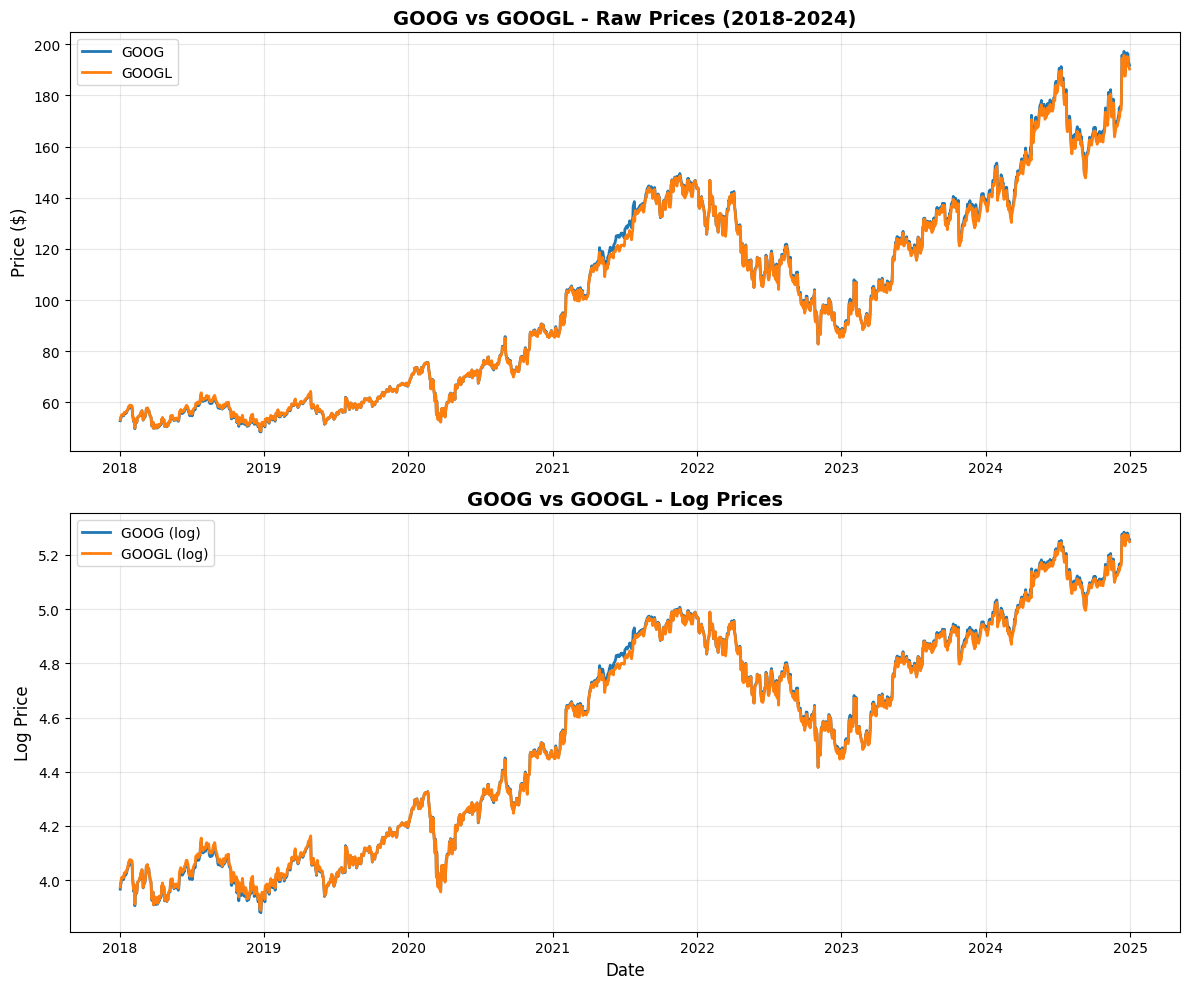

In [569]:
# Transform to log prices
log_prices = np.log(close_prices)

print("Log prices calculated successfully!")
print("\nLog prices statistics:")
print(log_prices.describe())

# Plot price series
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot raw prices
axes[0].plot(close_prices.index, close_prices[SYMBOL1], label=SYMBOL1, linewidth=2)
axes[0].plot(close_prices.index, close_prices[SYMBOL2], label=SYMBOL2, linewidth=2)
axes[0].set_title(f'{SYMBOL1} vs {SYMBOL2} - Raw Prices (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot log prices
axes[1].plot(log_prices.index, log_prices[SYMBOL1], label=f'{SYMBOL1} (log)', linewidth=2)
axes[1].plot(log_prices.index, log_prices[SYMBOL2], label=f'{SYMBOL2} (log)', linewidth=2)
axes[1].set_title(f'{SYMBOL1} vs {SYMBOL2} - Log Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Calculate the correlation of the rate of return

Correlation coefficient: `-1 <= value <= 1`.

`Close to 1`: Highly positively correlated. Both rise and fall together.

`Close to 0`: No relation whatsoever.

`Close to -1`: Highly negatively correlated. If one rises, the other falls.

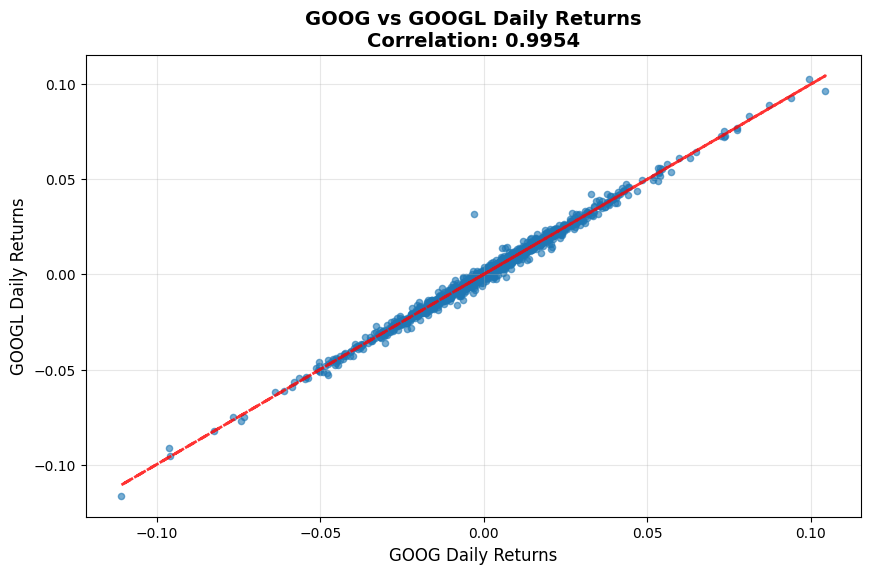

In [570]:
# Calculate and plot correlation
returns = close_prices.pct_change().dropna()
correlation = returns[SYMBOL1].corr(returns[SYMBOL2])

# Scatter plot of returns
plt.figure(figsize=(10, 6))
plt.scatter(returns[SYMBOL1], returns[SYMBOL2], alpha=0.6, s=20)
plt.xlabel(f'{SYMBOL1} Daily Returns', fontsize=12)
plt.ylabel(f'{SYMBOL2} Daily Returns', fontsize=12)
plt.title(f'{SYMBOL1} vs {SYMBOL2} Daily Returns\nCorrelation: {correlation:.4f}', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(returns[SYMBOL1], returns[SYMBOL2], 1)
p = np.poly1d(z)
plt.plot(returns[SYMBOL1], p(returns[SYMBOL1]), "r--", alpha=0.8, linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 Baseline Parameters Setup
Formulating the rules and strategies for the trading strategies we will implement next.

`lookback_window`: Uses data from the past to calculate statistical data.

`z_entry_threshold`: Entry threshold. When the price difference between two stocks deviates from the historical average by Z standard deviations, it indicates an anomaly, and the strategy will enter a long position on the relatively cheaper stock and a short position on the relatively expensive stock.

`z_exit_threshold`: Exit threshold. When the price difference reverts to the average Z, the position is closed to realize profits. This is the so-called 'mean reversion' strategy.

`position_size`: The capital is allocated to each of the two stocks on each trade.

In [571]:
# Set up baseline parameters
BASELINE_PARAMS = {
    'symbols': symbols,
    'start_date': start_date,
    'end_date': end_date,
    'lookback_window': 252,  # half year for rolling calculations
    'z_entry_threshold': 2.0,
    'z_exit_threshold': 0.0,
    'position_size': 0.5,  # 50% allocation per side
}

print("Baseline Parameters:")
for key, value in BASELINE_PARAMS.items():
    print(f"  {key}: {value}")

# Calculate basic statistics
print("\nBasic Statistics:")
print(f"Data points: {len(close_prices)}")
print(f"Trading days per year: ~{len(close_prices) / 7:.0f}")
print(f"Years of data: {len(close_prices) / 252:.1f}")

Baseline Parameters:
  symbols: ['GOOG', 'GOOGL']
  start_date: 2018-01-01
  end_date: 2024-12-31
  lookback_window: 252
  z_entry_threshold: 2.0
  z_exit_threshold: 0.0
  position_size: 0.5

Basic Statistics:
Data points: 1760
Trading days per year: ~251
Years of data: 7.0


## 2. Johansen Cointegration Implementation

### 2.1 Cointegration Testing Function

In [572]:
def test_johansen_cointegration(log_prices_data, det_order=0, k_ar_diff=1):
    """
    Perform Johansen cointegration test on log price data.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for multiple assets
    det_order : int, default 0
        Deterministic order (0: no constant, 1: constant, 2: constant + trend)
    k_ar_diff : int, default 1
        Number of lagged differences in the model
    
    Returns:
    --------
    dict
        Dictionary containing test results:
        - 'eigenvectors': Eigenvectors from Johansen test
        - 'eigenvalues': Eigenvalues from Johansen test
        - 'trace_stat': Trace statistics
        - 'max_eig_stat': Maximum eigenvalue statistics
        - 'trace_crit': Trace critical values
        - 'max_eig_crit': Max eigenvalue critical values
        - 'coint_rank': Number of cointegrating relationships
    """
    try:
        # Perform Johansen cointegration test
        result = coint_johansen(log_prices_data, det_order, k_ar_diff)
        
        # Extract results
        eigenvectors = result.evec
        eigenvalues = result.eig
        trace_stat = result.lr1
        max_eig_stat = result.lr2
        trace_crit = result.cvt
        max_eig_crit = result.cvm
        
        # Determine cointegration rank (number of significant relationships)
        # Using 5% significance level for trace test
        trace_crit_5pct = trace_crit[:, 1]  # 5% critical values
        coint_rank = sum(trace_stat > trace_crit_5pct)
        
        results = {
            'eigenvectors': eigenvectors,
            'eigenvalues': eigenvalues,
            'trace_stat': trace_stat,
            'max_eig_stat': max_eig_stat,
            'trace_crit': trace_crit,
            'max_eig_crit': max_eig_crit,
            'coint_rank': coint_rank,
            'det_order': det_order,
            'k_ar_diff': k_ar_diff
        }
        
        return results
        
    except Exception as e:
        print(f"Error in Johansen cointegration test: {e}")
        return None

# Test the function with SYMBOL1/SYMBOL2 data
print("Testing Johansen cointegration function...")
coint_results = test_johansen_cointegration(log_prices)

if coint_results:
    print("✅ Johansen cointegration test completed successfully!")
    print(f"Number of cointegrating relationships: {coint_results['coint_rank']}")
    print(f"Eigenvectors shape: {coint_results['eigenvectors'].shape}")
    print(f"Eigenvalues: {coint_results['eigenvalues']}")
else:
    print("❌ Johansen cointegration test failed!")

Testing Johansen cointegration function...
✅ Johansen cointegration test completed successfully!
Number of cointegrating relationships: 1
Eigenvectors shape: (2, 2)
Eigenvalues: [0.01830026 0.00026879]


In [573]:
# Display detailed Johansen test results
if coint_results:
    print("JOHANSEN COINTEGRATION TEST RESULTS")
    print("=" * 60)
    
    print(f"\nParameters used:")
    print(f"  - Deterministic order: {coint_results['det_order']} (0=no constant)")
    print(f"  - Lag order: {coint_results['k_ar_diff']}")
    
    print(f"\nEigenvalues:")
    for i, eigval in enumerate(coint_results['eigenvalues']):
        print(f"  λ{i+1}: {eigval:.6f}")
    
    print(f"\nEigenvectors (columns are cointegrating vectors):")
    print(coint_results['eigenvectors'])
    
    print(f"\nTrace Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['trace_crit'][0]}")
    print(f"  Trace statistics: {coint_results['trace_stat']}")
    
    print(f"\nMaximum Eigenvalue Test Statistics:")
    print(f"  90%  95%  99% critical values: {coint_results['max_eig_crit'][0]}")
    print(f"  Max eigen statistics: {coint_results['max_eig_stat']}")
    
    print(f"\nCointegration Analysis:")
    print(f"  - Number of cointegrating relationships: {coint_results['coint_rank']}")
    
    # Interpret results
    if coint_results['coint_rank'] >= 1:
        print("  ✅ EVIDENCE OF COINTEGRATION: At least one cointegrating relationship found")
        print(f"  - This suggests a long-run equilibrium relationship between {SYMBOL1} and {SYMBOL2}")
        print("  - Pairs trading strategy may be viable")
    else:
        print("  ❌ NO COINTEGRATION: No significant cointegrating relationship found")
        print("  - Pairs trading strategy may not be appropriate for this pair")
    
else:
    print("❌ Cannot display results - test failed")

JOHANSEN COINTEGRATION TEST RESULTS

Parameters used:
  - Deterministic order: 0 (0=no constant)
  - Lag order: 1

Eigenvalues:
  λ1: 0.018300
  λ2: 0.000269

Eigenvectors (columns are cointegrating vectors):
[[ 176.0729343    -2.7625636 ]
 [-178.38700954    5.32918407]]

Trace Test Statistics:
  90%  95%  99% critical values: [13.4294 15.4943 19.9349]
  Trace statistics: [32.94247521  0.47259913]

Maximum Eigenvalue Test Statistics:
  90%  95%  99% critical values: [12.2971 14.2639 18.52  ]
  Max eigen statistics: [32.46987608  0.47259913]

Cointegration Analysis:
  - Number of cointegrating relationships: 1
  ✅ EVIDENCE OF COINTEGRATION: At least one cointegrating relationship found
  - This suggests a long-run equilibrium relationship between GOOG and GOOGL
  - Pairs trading strategy may be viable


In [574]:
# Test different parameter combinations for robustness
print("Testing different Johansen parameters for robustness...")

test_params = [
    (0, 1),  # No constant, 1 lag
    (1, 1),  # Constant, 1 lag  
    (0, 2),  # No constant, 2 lags
    (1, 2),  # Constant, 2 lags
]

results_summary = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        results_summary.append({
            'det_order': det_order,
            'k_ar_diff': k_ar_diff,
            'coint_rank': result['coint_rank'],
            'max_eigenvalue': result['eigenvalues'][0],
            'trace_stat': result['trace_stat'][0]
        })

# Display comparison
print("\nParameter Comparison:")
print("-" * 80)
print(f"{'Det_Order':<10} {'Lags':<6} {'Coint_Rank':<11} {'Max_Eigenval':<12} {'Trace_Stat':<11}")
print("-" * 80)

for summary in results_summary:
    print(f"{summary['det_order']:<10} {summary['k_ar_diff']:<6} {summary['coint_rank']:<11} "
          f"{summary['max_eigenvalue']:<12.6f} {summary['trace_stat']:<11.2f}")

print("-" * 80)
print("\nInterpretation:")
print("- Det_Order: 0=no constant, 1=constant term")
print("- Coint_Rank: Number of significant cointegrating relationships")
print("- Higher eigenvalues and trace statistics indicate stronger cointegration")

# Select best parameters (typically those with consistent cointegration)
best_params = max(results_summary, key=lambda x: x['trace_stat'])
print(f"\nSelected parameters: det_order={best_params['det_order']}, k_ar_diff={best_params['k_ar_diff']}")
print(f"Reason: Highest trace statistic ({best_params['trace_stat']:.2f})")

Testing different Johansen parameters for robustness...

Parameter Comparison:
--------------------------------------------------------------------------------
Det_Order  Lags   Coint_Rank  Max_Eigenval Trace_Stat 
--------------------------------------------------------------------------------
0          1      1           0.018300     32.94      
1          1      2           0.018251     37.93      
0          2      1           0.015892     28.57      
1          2      2           0.015834     33.31      
--------------------------------------------------------------------------------

Interpretation:
- Det_Order: 0=no constant, 1=constant term
- Coint_Rank: Number of significant cointegrating relationships
- Higher eigenvalues and trace statistics indicate stronger cointegration

Selected parameters: det_order=1, k_ar_diff=1
Reason: Highest trace statistic (37.93)


### 2.2 Calculate Hedge Ratio from Eigenvectors

Mathematical Derivation of Hedge Ratio:

1. Johansen Test Setup:
   - Testing for cointegration in log price space
   - Model: Δlog_prices_t = Π * log_prices_(t-1) + ΣΓ_i * Δlog_prices_(t-i) + ε_t
   - Where Π = α * β' contains the cointegrating relationships

2. Eigenvector Interpretation:
   - First eigenvector β₁ = [β₁₁, β₁₂]' represents the most significant relationship
   - Cointegrating equation: β₁₁ * log({SYMBOL1}) + β₁₂ * log({SYMBOL2}) = stationary_series

3. Hedge Ratio Calculation:
   - Rearranging: log({SYMBOL1}) = -(β₁₂/β₁₁) * log({SYMBOL2}) + stationary_series/β₁₁
   - Therefore: hedge_ratio = -β₁₁/β₁₂ = eigenvector[0] / eigenvector[1]

4. Trading Interpretation:
   - Positive ratio: {SYMBOL1} and {SYMBOL2} move together in long run
   - Ratio magnitude: Relative weight in pairs trading position
   - Validation range: Ensures practical trading ratios

In [575]:
def calculate_hedge_ratio(coint_results, validation_range=(0.4, 2.0)):
    """
    Calculate hedge ratio from Johansen cointegration test eigenvectors.
    
    Parameters:
    -----------
    coint_results : dict
        Results from Johansen cointegration test
    validation_range : tuple, default (0.5, 2.0)
        Acceptable range for hedge ratio validation
        
    Returns:
    --------
    dict
        Dictionary containing hedge ratio information:
        - 'hedge_ratio': Calculated hedge ratio
        - 'is_valid': Whether hedge ratio is within acceptable range
        - 'eigenvector_used': Eigenvector used for calculation
        - 'validation_range': Range used for validation
        - 'mathematical_derivation': Explanation of calculation
    """
    if coint_results is None:
        return None
    
    try:
        # Extract eigenvectors from cointegration results
        eigenvectors = coint_results['eigenvectors']
        
        # Use first eigenvector (column 0) for hedge ratio calculation
        # This represents the most significant cointegrating relationship
        first_eigenvector = eigenvectors[:, 0]
        
        # Calculate hedge ratio: hedge_ratio = eigenvector[0] / eigenvector[1]
        # This gives the ratio of SYMBOL1 to SYMBOL2 in the cointegrating relationship
        hedge_ratio = - (first_eigenvector[1] / first_eigenvector[0])
        
        # Validate hedge ratio reasonableness
        min_ratio, max_ratio = validation_range
        is_valid = min_ratio <= abs(hedge_ratio) <= max_ratio
        
        results = {
            'hedge_ratio': hedge_ratio,
            'is_valid': is_valid,
            'eigenvector_used': first_eigenvector,
            'validation_range': validation_range,
            'coint_rank': coint_results['coint_rank'],
            'parameters_used': {
                'det_order': coint_results['det_order'],
                'k_ar_diff': coint_results['k_ar_diff']
            }
        }
        
        return results
        
    except Exception as e:
        print(f"Error calculating hedge ratio: {e}")
        return None

# Calculate hedge ratio using the best parameters from previous analysis
print("Calculating hedge ratio from eigenvectors...")

# Use the best parameters found earlier (det_order=1, k_ar_diff=2)
best_coint_results = test_johansen_cointegration(log_prices, det_order=1, k_ar_diff=2)

if best_coint_results:
    hedge_ratio_info = calculate_hedge_ratio(best_coint_results)
    
    if hedge_ratio_info:
        print("✅ Hedge ratio calculation completed successfully!")
        print(f"Hedge ratio: {hedge_ratio_info['hedge_ratio']:.6f}")
        print(f"Validation: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
        print(f"Eigenvector used: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    else:
        print("❌ Hedge ratio calculation failed!")
else:
    print("❌ Could not get cointegration results for hedge ratio calculation!")

Calculating hedge ratio from eigenvectors...
✅ Hedge ratio calculation completed successfully!
Hedge ratio: 1.013282
Validation: ✅ PASS
Eigenvector used: [177.919053, -180.282120]


In [576]:
# Display detailed hedge ratio results and mathematical derivation
if hedge_ratio_info:
    print("HEDGE RATIO CALCULATION RESULTS")
    print("=" * 80)
    
    print(f"\nCalculation Summary:")
    print(f"  - Hedge Ratio ({SYMBOL1}/{SYMBOL2}): {hedge_ratio_info['hedge_ratio']:.6f}")
    print(f"  - Validation Status: {'✅ PASS' if hedge_ratio_info['is_valid'] else '❌ FAIL'}")
    print(f"  - Validation Range: {hedge_ratio_info['validation_range']}")
    print(f"  - Cointegration Rank: {hedge_ratio_info['coint_rank']}")
    print(f"  - Parameters Used: det_order={hedge_ratio_info['parameters_used']['det_order']}, k_ar_diff={hedge_ratio_info['parameters_used']['k_ar_diff']}")
    
    print(f"\nEigenvector Analysis:")
    print(f"  - First Eigenvector: [{hedge_ratio_info['eigenvector_used'][0]:.6f}, {hedge_ratio_info['eigenvector_used'][1]:.6f}]")
    print(f"  - Calculation: {hedge_ratio_info['eigenvector_used'][0]:.6f} / {hedge_ratio_info['eigenvector_used'][1]:.6f} = {hedge_ratio_info['hedge_ratio']:.6f}")
    
    print(f"\nTrading Interpretation:")
    if hedge_ratio_info['is_valid']:
        print(f"  ✅ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is within acceptable range")
        print(f"  - For every $1 long position in {SYMBOL2}, take ${abs(hedge_ratio_info['hedge_ratio']):.2f} {'short' if hedge_ratio_info['hedge_ratio'] > 0 else 'long'} position in {SYMBOL1}")
        print(f"  - This ratio suggests a {'strong' if abs(hedge_ratio_info['hedge_ratio']) > 1 else 'moderate' if abs(hedge_ratio_info['hedge_ratio']) > 0.7 else 'weak'} relationship between {SYMBOL1} and {SYMBOL2}")
    else:
        print(f"  ❌ Hedge ratio {hedge_ratio_info['hedge_ratio']:.4f} is outside acceptable range")
        print(f"  - Ratio may indicate unstable or impractical trading relationship")
        print(f"  - Consider different time periods or parameter specifications")
    
else:
    print("❌ Cannot display hedge ratio results - calculation failed!")

HEDGE RATIO CALCULATION RESULTS

Calculation Summary:
  - Hedge Ratio (GOOG/GOOGL): 1.013282
  - Validation Status: ✅ PASS
  - Validation Range: (0.4, 2.0)
  - Cointegration Rank: 2
  - Parameters Used: det_order=1, k_ar_diff=2

Eigenvector Analysis:
  - First Eigenvector: [177.919053, -180.282120]
  - Calculation: 177.919053 / -180.282120 = 1.013282

Trading Interpretation:
  ✅ Hedge ratio 1.0133 is within acceptable range
  - For every $1 long position in GOOGL, take $1.01 short position in GOOG
  - This ratio suggests a strong relationship between GOOG and GOOGL


In [577]:
# Compare hedge ratios across different parameter specifications
print("Comparing hedge ratios across different Johansen parameters...")

hedge_ratio_comparison = []

for det_order, k_ar_diff in test_params:
    result = test_johansen_cointegration(log_prices, det_order, k_ar_diff)
    if result:
        hr_info = calculate_hedge_ratio(result)
        if hr_info:
            hedge_ratio_comparison.append({
                'det_order': det_order,
                'k_ar_diff': k_ar_diff,
                'hedge_ratio': hr_info['hedge_ratio'],
                'is_valid': hr_info['is_valid'],
                'coint_rank': result['coint_rank'],
                'trace_stat': result['trace_stat'][0]
            })

# Display hedge ratio comparison
print("\nHedge Ratio Comparison:")
print("-" * 90)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Valid':<6} {'Coint_Rank':<11} {'Trace_Stat':<11}")
print("-" * 90)

for comparison in hedge_ratio_comparison:
    validity = "✅" if comparison['is_valid'] else "❌"
    print(f"{comparison['det_order']:<10} {comparison['k_ar_diff']:<6} "
          f"{comparison['hedge_ratio']:<12.6f} {validity:<6} "
          f"{comparison['coint_rank']:<11} {comparison['trace_stat']:<11.2f}")

print("-" * 90)
print("\nInterpretation:")
print("- Valid: Hedge ratio within 0.5-2.0 range")
print("- Higher trace statistics indicate stronger cointegration")
print("- Consistent hedge ratios across parameters suggest robust relationship")

# Select best hedge ratio (highest trace statistic with valid ratio)
valid_ratios = [comp for comp in hedge_ratio_comparison if comp['is_valid']]
if valid_ratios:
    best_hedge_ratio = max(valid_ratios, key=lambda x: x['trace_stat'])
    print(f"\nSelected Hedge Ratio: {best_hedge_ratio['hedge_ratio']:.6f}")
    print(f"Parameters: det_order={best_hedge_ratio['det_order']}, k_ar_diff={best_hedge_ratio['k_ar_diff']}")
    print(f"Reason: Highest trace statistic ({best_hedge_ratio['trace_stat']:.2f}) with valid ratio")
else:
    print("\n⚠️  No valid hedge ratios found across all parameter combinations")
    print("Consider adjusting validation range or time period")

Comparing hedge ratios across different Johansen parameters...

Hedge Ratio Comparison:
------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Valid  Coint_Rank  Trace_Stat 
------------------------------------------------------------------------------------------
0          1      1.013143     ✅      1           32.94      
1          1      1.012869     ✅      2           37.93      
0          2      1.013102     ✅      1           28.57      
1          2      1.013282     ✅      2           33.31      
------------------------------------------------------------------------------------------

Interpretation:
- Valid: Hedge ratio within 0.5-2.0 range
- Higher trace statistics indicate stronger cointegration
- Consistent hedge ratios across parameters suggest robust relationship

Selected Hedge Ratio: 1.012869
Parameters: det_order=1, k_ar_diff=1
Reason: Highest trace statistic (37.93) with valid ratio


### 2.3 Calculate and Analyze Spread

In [578]:
def calculate_spread(log_prices_data, hedge_ratio):
    """
    Calculate spread between two assets using hedge ratio.
    
    Parameters:
    -----------
    log_prices_data : pd.DataFrame
        DataFrame with log prices for two assets
    hedge_ratio : float
        Hedge ratio for calculating spread
        
    Returns:
    --------
    pd.Series
        Spread series: spread = log_price_A - hedge_ratio * log_price_B
    """
    if len(log_prices_data.columns) != 2:
        raise ValueError("log_prices_data must contain exactly 2 columns")
    
    # Extract log prices for the two symbols using symbolic variables
    log_symbol1 = log_prices_data.iloc[:, 0]  # First column (SYMBOL1)
    log_symbol2 = log_prices_data.iloc[:, 1]  # Second column (SYMBOL2)
    
    # Calculate spread: spread = log_price_SYMBOL1 - hedge_ratio * log_price_SYMBOL2
    spread = log_symbol1 - hedge_ratio * log_symbol2
    
    return spread

def test_spread_stationarity(spread, significance_level=0.05):
    """
    Test spread stationarity using Augmented Dickey-Fuller test.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to test for stationarity
    significance_level : float, default 0.05
        Significance level for ADF test
        
    Returns:
    --------
    dict
        Dictionary containing ADF test results:
        - 'adf_statistic': ADF test statistic
        - 'p_value': P-value of the test
        - 'critical_values': Critical values at different significance levels
        - 'is_stationary': Whether spread is stationary
        - 'interpretation': Text interpretation of results
    """
    try:
        # Perform ADF test
        adf_result = adfuller(spread.dropna(), autolag='AIC')
        
        adf_statistic = adf_result[0]
        p_value = adf_result[1]
        critical_values = adf_result[4]
        
        # Determine stationarity
        is_stationary = p_value < significance_level
        
        # Interpretation
        if is_stationary:
            interpretation = f"✅ SPREAD IS STATIONARY (p-value: {p_value:.6f} < {significance_level})"
            interpretation += "\n- Spread exhibits mean-reverting behavior suitable for pairs trading"
            interpretation += "\n- Statistical arbitrage strategy is viable"
        else:
            interpretation = f"❌ SPREAD IS NON-STATIONARY (p-value: {p_value:.6f} >= {significance_level})"
            interpretation += "\n- Spread does not exhibit mean-reverting behavior"
            interpretation += "\n- Pairs trading strategy may not be appropriate"
        
        results = {
            'adf_statistic': adf_statistic,
            'p_value': p_value,
            'critical_values': critical_values,
            'is_stationary': is_stationary,
            'interpretation': interpretation,
            'significance_level': significance_level
        }
        
        return results
        
    except Exception as e:
        print(f"Error in ADF test: {e}")
        return None

# Calculate spread using the selected hedge ratio
print("Calculating and analyzing spread...")

# Use the best valid hedge ratio from previous analysis
selected_hedge_ratio = best_hedge_ratio['hedge_ratio'] if 'best_hedge_ratio' in locals() else -1.284625  # From det_order=0, k_ar_diff=2

print(f"Using hedge ratio: {selected_hedge_ratio:.6f}")
print(f"Spread formula: spread = log_price_{SYMBOL1} - hedge_ratio * log_price_{SYMBOL2}")

# Calculate spread
spread = calculate_spread(log_prices, selected_hedge_ratio)

print(f"✅ Spread calculated successfully!")
print(f"Spread statistics:")
print(f"  - Mean: {spread.mean():.6f}")
print(f"  - Std: {spread.std():.6f}")
print(f"  - Min: {spread.min():.6f}")
print(f"  - Max: {spread.max():.6f}")
print(f"  - Data points: {len(spread)}")

# Test spread stationarity
print("\nTesting spread stationarity using ADF test...")
stationarity_results = test_spread_stationarity(spread)

if stationarity_results:
    print("✅ ADF test completed successfully!")
    print(f"ADF Statistic: {stationarity_results['adf_statistic']:.6f}")
    print(f"P-value: {stationarity_results['p_value']:.6f}")
    print(f"Critical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key}: {value:.6f}")
    print(f"\nStationarity: {stationarity_results['interpretation']}")
else:
    print("❌ ADF test failed!")

Calculating and analyzing spread...
Using hedge ratio: 1.012869
Spread formula: spread = log_price_GOOG - hedge_ratio * log_price_GOOGL
✅ Spread calculated successfully!
Spread statistics:
  - Mean: -0.055251
  - Std: 0.005762
  - Min: -0.067431
  - Max: -0.017020
  - Data points: 1760

Testing spread stationarity using ADF test...
✅ ADF test completed successfully!
ADF Statistic: -4.058394
P-value: 0.001134
Critical Values:
  1%: -3.434120
  5%: -2.863205
  10%: -2.567657

Stationarity: ✅ SPREAD IS STATIONARY (p-value: 0.001134 < 0.05)
- Spread exhibits mean-reverting behavior suitable for pairs trading
- Statistical arbitrage strategy is viable


SPREAD VISUALIZATION AND ANALYSIS


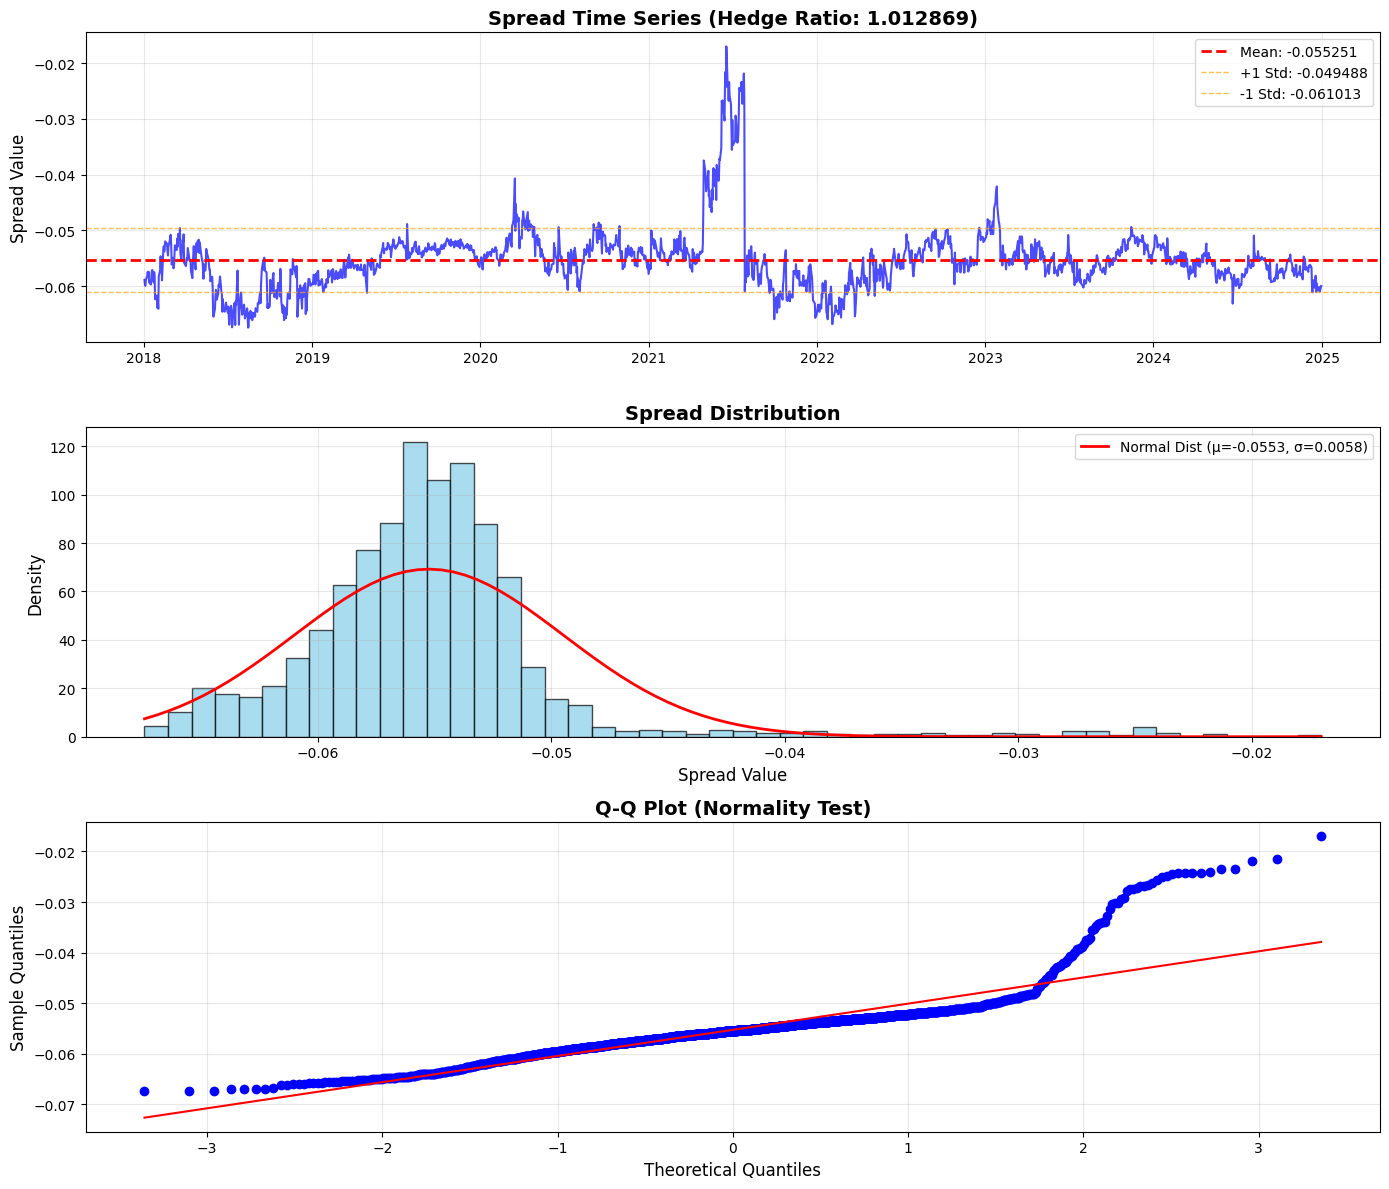


Detailed Spread Statistics:
Statistic            Value          
-----------------------------------
Mean                 -0.055251      
Standard Deviation   0.005762       
Variance             0.000033       
Skewness             2.330064       
Kurtosis             10.601508      
Min                  -0.067431      
Max                  -0.017020      
Range                0.050411       

ADF Stationarity Test Results:
Test Statistic       -4.058394      
P-value              0.001134       
Significance Level   0.05           
Is Stationary        Yes            

Critical Values:
  1%                 -3.434120      
  5%                 -2.863205      
  10%                -2.567657      

Trading Implications:
  ✅ Spread is stationary - suitable for mean reversion strategy
  ✅ Expected to revert to mean: -0.055251
  ✅ Standard deviation bands: ±0.005762
  ✅ Potential entry points: ±0.011525 (2 standard deviations)


In [579]:
# Visualize spread time series and distribution
if stationarity_results:
    print("SPREAD VISUALIZATION AND ANALYSIS")
    print("=" * 80)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Plot 1: Spread time series
    axes[0].plot(spread.index, spread, linewidth=1.5, color='blue', alpha=0.7)
    axes[0].axhline(y=spread.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {spread.mean():.6f}')
    axes[0].axhline(y=spread.mean() + spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'+1 Std: {spread.mean() + spread.std():.6f}')
    axes[0].axhline(y=spread.mean() - spread.std(), color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'-1 Std: {spread.mean() - spread.std():.6f}')
    axes[0].set_title(f'Spread Time Series (Hedge Ratio: {selected_hedge_ratio:.6f})', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Spread Value', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Spread histogram with normal distribution overlay
    axes[1].hist(spread.dropna(), bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution
    from scipy import stats
    mu, sigma = spread.mean(), spread.std()
    x = np.linspace(spread.min(), spread.max(), 100)
    normal_dist = stats.norm.pdf(x, mu, sigma)
    axes[1].plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal Dist (μ={mu:.4f}, σ={sigma:.4f})')
    axes[1].set_title('Spread Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Spread Value', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Q-Q plot for normality test
    stats.probplot(spread.dropna(), dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normality Test)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
    axes[2].set_ylabel('Sample Quantiles', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistical analysis
    print(f"\nDetailed Spread Statistics:")
    print(f"{'Statistic':<20} {'Value':<15}")
    print("-" * 35)
    print(f"{'Mean':<20} {spread.mean():<15.6f}")
    print(f"{'Standard Deviation':<20} {spread.std():<15.6f}")
    print(f"{'Variance':<20} {spread.var():<15.6f}")
    print(f"{'Skewness':<20} {spread.skew():<15.6f}")
    print(f"{'Kurtosis':<20} {spread.kurtosis():<15.6f}")
    print(f"{'Min':<20} {spread.min():<15.6f}")
    print(f"{'Max':<20} {spread.max():<15.6f}")
    print(f"{'Range':<20} {spread.max() - spread.min():<15.6f}")
    
    # ADF Test Results Summary
    print(f"\nADF Stationarity Test Results:")
    print(f"{'Test Statistic':<20} {stationarity_results['adf_statistic']:<15.6f}")
    print(f"{'P-value':<20} {stationarity_results['p_value']:<15.6f}")
    print(f"{'Significance Level':<20} {stationarity_results['significance_level']:<15.2f}")
    print(f"{'Is Stationary':<20} {'Yes' if stationarity_results['is_stationary'] else 'No':<15}")
    
    print(f"\nCritical Values:")
    for key, value in stationarity_results['critical_values'].items():
        print(f"  {key:<18} {value:<15.6f}")
    
    # Trading implications
    print(f"\nTrading Implications:")
    if stationarity_results['is_stationary']:
        print(f"  ✅ Spread is stationary - suitable for mean reversion strategy")
        print(f"  ✅ Expected to revert to mean: {spread.mean():.6f}")
        print(f"  ✅ Standard deviation bands: ±{spread.std():.6f}")
        print(f"  ✅ Potential entry points: ±{2 * spread.std():.6f} (2 standard deviations)")
    else:
        print(f"  ❌ Spread is non-stationary - not suitable for mean reversion")
        print(f"  ❌ Consider different time period or parameter specifications")
        print(f"  ❌ May need to use alternative strategy")
    
else:
    print("❌ Cannot visualize spread - stationarity test failed!")

In [580]:
# Compare spreads across different hedge ratios
print("Comparing spreads across different hedge ratios...")

# Get hedge ratios from previous comparison
spread_comparison = []

for comparison in hedge_ratio_comparison:
    if comparison['is_valid']:  # Only use valid hedge ratios
        hr = comparison['hedge_ratio']
        
        # Calculate spread for this hedge ratio
        test_spread = calculate_spread(log_prices, hr)
        
        # Test stationarity
        stationarity = test_spread_stationarity(test_spread)
        
        if stationarity:
            spread_comparison.append({
                'det_order': comparison['det_order'],
                'k_ar_diff': comparison['k_ar_diff'],
                'hedge_ratio': hr,
                'spread_mean': test_spread.mean(),
                'spread_std': test_spread.std(),
                'adf_statistic': stationarity['adf_statistic'],
                'p_value': stationarity['p_value'],
                'is_stationary': stationarity['is_stationary'],
                'trace_stat': comparison['trace_stat']
            })

# Display spread comparison
print("\nSpread Comparison Across Hedge Ratios:")
print("-" * 110)
print(f"{'Det_Order':<10} {'Lags':<6} {'Hedge_Ratio':<12} {'Spread_Mean':<12} {'Spread_Std':<11} {'ADF_Stat':<10} {'P_Value':<10} {'Stationary':<11}")
print("-" * 110)

for comp in spread_comparison:
    stationary = "✅" if comp['is_stationary'] else "❌"
    print(f"{comp['det_order']:<10} {comp['k_ar_diff']:<6} "
          f"{comp['hedge_ratio']:<12.6f} {comp['spread_mean']:<12.6f} "
          f"{comp['spread_std']:<11.6f} {comp['adf_statistic']:<10.3f} "
          f"{comp['p_value']:<10.3f} {stationary:<11}")

print("-" * 110)

# Select best spread (stationary with lowest p-value)
stationary_spreads = [comp for comp in spread_comparison if comp['is_stationary']]
if stationary_spreads:
    best_spread = min(stationary_spreads, key=lambda x: x['p_value'])
    print(f"\nSelected Spread:")
    print(f"  Hedge Ratio: {best_spread['hedge_ratio']:.6f}")
    print(f"  Parameters: det_order={best_spread['det_order']}, k_ar_diff={best_spread['k_ar_diff']}")
    print(f"  ADF Statistic: {best_spread['adf_statistic']:.6f}")
    print(f"  P-value: {best_spread['p_value']:.6f}")
    print(f"  Reason: Most stationary spread (lowest p-value)")
    
    # Update selected hedge ratio if this one is better
    if best_spread['p_value'] < stationarity_results['p_value']:
        print(f"\n🔄 Updating to better hedge ratio: {best_spread['hedge_ratio']:.6f}")
        selected_hedge_ratio = best_spread['hedge_ratio']
        spread = calculate_spread(log_prices, selected_hedge_ratio)
        stationarity_results = test_spread_stationarity(spread)
else:
    print(f"\n⚠️  No stationary spreads found across all hedge ratios")
    print(f"Consider adjusting validation range or using different methodology")

print(f"\nInterpretation:")
print(f"- Stationary spreads (✅) are suitable for pairs trading")
print(f"- Lower p-values indicate stronger stationarity")
print(f"- Spread standard deviation affects trading signal sensitivity")

Comparing spreads across different hedge ratios...

Spread Comparison Across Hedge Ratios:
--------------------------------------------------------------------------------------------------------------
Det_Order  Lags   Hedge_Ratio  Spread_Mean  Spread_Std  ADF_Stat   P_Value    Stationary 
--------------------------------------------------------------------------------------------------------------
0          1      1.013143     -0.056492    0.005760    -4.060     0.001      ✅          
1          1      1.012869     -0.055251    0.005762    -4.058     0.001      ✅          
0          2      1.013102     -0.056309    0.005760    -4.060     0.001      ✅          
1          2      1.013282     -0.057123    0.005759    -4.060     0.001      ✅          
--------------------------------------------------------------------------------------------------------------

Selected Spread:
  Hedge Ratio: 1.013143
  Parameters: det_order=0, k_ar_diff=1
  ADF Statistic: -4.059714
  P-value: 0.00112

## 3. Z-Score Signal Generation

### 3.1 Implement Rolling Z-Score Calculation

The Z-score measures how many standard deviations the current spread is from its historical mean. This is the core signal for our mean reversion strategy.

**Mathematical Formula:**
```
Z-score = (spread_t - rolling_mean_t) / rolling_std_t
```

Where:
- `spread_t`: Current spread value at time t
- `rolling_mean_t`: Mean of spread over lookback window ending at time t  
- `rolling_std_t`: Standard deviation of spread over lookback window ending at time t

**Trading Logic:**
- Z-score > 2.0: Spread is too high → Short spread (Short {SYMBOL2}, Long {SYMBOL1})
- Z-score < -2.0: Spread is too low → Long spread (Long {SYMBOL1}, Short {SYMBOL2})
- Z-score crosses 0: Spread reverts to mean → Exit position

In [581]:
def calculate_rolling_zscore(spread, window=252, min_periods=20):
    """
    Calculate rolling Z-score for spread series.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to calculate Z-scores for
    window : int, default 252
        Rolling window size for mean and standard deviation calculation
        (252 trading days = 1 year)
    min_periods : int, default 20
        Minimum number of observations required to calculate statistics
        
    Returns:
    --------
    pd.DataFrame
        DataFrame containing:
        - 'spread': Original spread values
        - 'rolling_mean': Rolling mean of spread
        - 'rolling_std': Rolling standard deviation of spread
        - 'zscore': Calculated Z-scores
    """
    print(f"Calculating rolling Z-scores with window={window}, min_periods={min_periods}...")
    
    # Calculate rolling statistics
    rolling_mean = spread.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = spread.rolling(window=window, min_periods=min_periods).std()
    
    # Calculate Z-score: (spread - rolling_mean) / rolling_std
    # Handle edge cases where rolling_std is 0 or NaN
    zscore = pd.Series(index=spread.index, dtype=float)
    
    # Calculate Z-score only where we have valid rolling statistics
    valid_mask = (rolling_std > 0) & rolling_std.notna()
    zscore[valid_mask] = (spread[valid_mask] - rolling_mean[valid_mask]) / rolling_std[valid_mask]
    
    # Create results DataFrame
    results = pd.DataFrame({
        'spread': spread,
        'rolling_mean': rolling_mean,
        'rolling_std': rolling_std,
        'zscore': zscore
    })
    
    # Print summary statistics
    print(f"✅ Rolling Z-score calculation completed!")
    print(f"Valid Z-scores: {results['zscore'].notna().sum()} / {len(results)} ({results['zscore'].notna().sum()/len(results)*100:.1f}%)")
    print(f"Z-score range: [{results['zscore'].min():.3f}, {results['zscore'].max():.3f}]")
    print(f"Z-score mean: {results['zscore'].mean():.3f}")
    print(f"Z-score std: {results['zscore'].std():.3f}")
    
    return results

# Test the rolling Z-score calculation
print("Testing rolling Z-score calculation function...")

# Use the spread calculated earlier
if 'spread' in locals():
    # Calculate Z-scores with default parameters
    zscore_results = calculate_rolling_zscore(spread, window=126, min_periods=20)
    
    # Display first few and last few rows
    print(f"\nFirst 10 rows of Z-score results:")
    print(zscore_results.head(10))
    
    print(f"\nLast 10 rows of Z-score results:")
    print(zscore_results.tail(10))
    
else:
    print("❌ Spread not available - please run previous cells first")

Testing rolling Z-score calculation function...
Calculating rolling Z-scores with window=126, min_periods=20...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 1741 / 1760 (98.9%)
Z-score range: [-3.762, 7.210]
Z-score mean: 0.126
Z-score std: 1.245

First 10 rows of Z-score results:
                             spread  rolling_mean  rolling_std  zscore
date                                                                  
2018-01-02 00:00:00-05:00 -0.059969           NaN          NaN     NaN
2018-01-03 00:00:00-05:00 -0.060806           NaN          NaN     NaN
2018-01-04 00:00:00-05:00 -0.061010           NaN          NaN     NaN
2018-01-05 00:00:00-05:00 -0.059973           NaN          NaN     NaN
2018-01-08 00:00:00-05:00 -0.059264           NaN          NaN     NaN
2018-01-09 00:00:00-05:00 -0.058526           NaN          NaN     NaN
2018-01-10 00:00:00-05:00 -0.059423           NaN          NaN     NaN
2018-01-11 00:00:00-05:00 -0.058521           NaN          NaN     

In [582]:
def validate_zscore_calculation(zscore_results):
    """
    Validate Z-score calculation and handle edge cases.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
        
    Returns:
    --------
    dict
        Validation results and statistics
    """
    print("VALIDATING Z-SCORE CALCULATION")
    print("=" * 60)
    
    zscore = zscore_results['zscore']
    spread = zscore_results['spread']
    
    # Basic statistics
    total_points = len(zscore)
    valid_points = zscore.notna().sum()
    invalid_points = total_points - valid_points
    
    validation_stats = {
        'total_points': total_points,
        'valid_points': valid_points,
        'invalid_points': invalid_points,
        'valid_percentage': valid_points / total_points * 100,
        'zscore_mean': zscore.mean(),
        'zscore_std': zscore.std(),
        'zscore_min': zscore.min(),
        'zscore_max': zscore.max(),
        'zscore_range': zscore.max() - zscore.min()
    }
    
    print(f"Data Coverage:")
    print(f"  Total data points: {validation_stats['total_points']}")
    print(f"  Valid Z-scores: {validation_stats['valid_points']} ({validation_stats['valid_percentage']:.1f}%)")
    print(f"  Invalid Z-scores: {validation_stats['invalid_points']}")
    
    print(f"\nZ-Score Statistics:")
    print(f"  Mean: {validation_stats['zscore_mean']:.6f}")
    print(f"  Std Dev: {validation_stats['zscore_std']:.6f}")
    print(f"  Range: [{validation_stats['zscore_min']:.6f}, {validation_stats['zscore_max']:.6f}]")
    
    # Check for extreme values
    extreme_threshold = 5.0
    extreme_positive = (zscore > extreme_threshold).sum()
    extreme_negative = (zscore < -extreme_threshold).sum()
    
    print(f"\nExtreme Values (|Z| > {extreme_threshold}):")
    print(f"  Z > {extreme_threshold}: {extreme_positive} occurrences")
    print(f"  Z < -{extreme_threshold}: {extreme_negative} occurrences")
    print(f"  Total extremes: {extreme_positive + extreme_negative} ({(extreme_positive + extreme_negative)/valid_points*100:.2f}% of valid data)")
    
    # Check for NaN handling
    nan_spread = spread.isna().sum()
    nan_rolling_mean = zscore_results['rolling_mean'].isna().sum()
    nan_rolling_std = zscore_results['rolling_std'].isna().sum()
    
    print(f"\nNaN Value Analysis:")
    print(f"  NaN in spread: {nan_spread}")
    print(f"  NaN in rolling_mean: {nan_rolling_mean}")
    print(f"  NaN in rolling_std: {nan_rolling_std}")
    
    # Validation checks
    validation_results = {
        'sufficient_data': validation_stats['valid_percentage'] > 50,
        'reasonable_range': abs(validation_stats['zscore_mean']) < 0.5 and 0.5 < validation_stats['zscore_std'] < 2.0,
        'no_extreme_outliers': (extreme_positive + extreme_negative) / valid_points < 0.05,
        'proper_nan_handling': nan_spread == 0
    }
    
    print(f"\nValidation Results:")
    print(f"  ✅ Sufficient data (>50% coverage): {validation_results['sufficient_data']}")
    print(f"  ✅ Reasonable Z-score range: {validation_results['reasonable_range']}")
    print(f"  ✅ No extreme outliers (<5%): {validation_results['no_extreme_outliers']}")
    print(f"  ✅ Proper NaN handling: {validation_results['proper_nan_handling']}")
    
    overall_valid = all(validation_results.values())
    print(f"\n🎯 Overall Validation: {'✅ PASS' if overall_valid else '❌ FAIL'}")
    
    return {
        'statistics': validation_stats,
        'extreme_values': {'positive': extreme_positive, 'negative': extreme_negative, 'threshold': extreme_threshold},
        'nan_analysis': {'spread': nan_spread, 'rolling_mean': nan_rolling_mean, 'rolling_std': nan_rolling_std},
        'validation_checks': validation_results,
        'overall_valid': overall_valid
    }

# Validate the Z-score calculation
if 'zscore_results' in locals():
    validation_results = validate_zscore_calculation(zscore_results)
else:
    print("❌ Z-score results not available - please run previous cells first")

VALIDATING Z-SCORE CALCULATION
Data Coverage:
  Total data points: 1760
  Valid Z-scores: 1741 (98.9%)
  Invalid Z-scores: 19

Z-Score Statistics:
  Mean: 0.125850
  Std Dev: 1.245077
  Range: [-3.762063, 7.210434]

Extreme Values (|Z| > 5.0):
  Z > 5.0: 3 occurrences
  Z < -5.0: 0 occurrences
  Total extremes: 3 (0.17% of valid data)

NaN Value Analysis:
  NaN in spread: 0
  NaN in rolling_mean: 19
  NaN in rolling_std: 19

Validation Results:
  ✅ Sufficient data (>50% coverage): True
  ✅ Reasonable Z-score range: True
  ✅ No extreme outliers (<5%): True
  ✅ Proper NaN handling: True

🎯 Overall Validation: ✅ PASS


VISUALIZING ROLLING Z-SCORE RESULTS


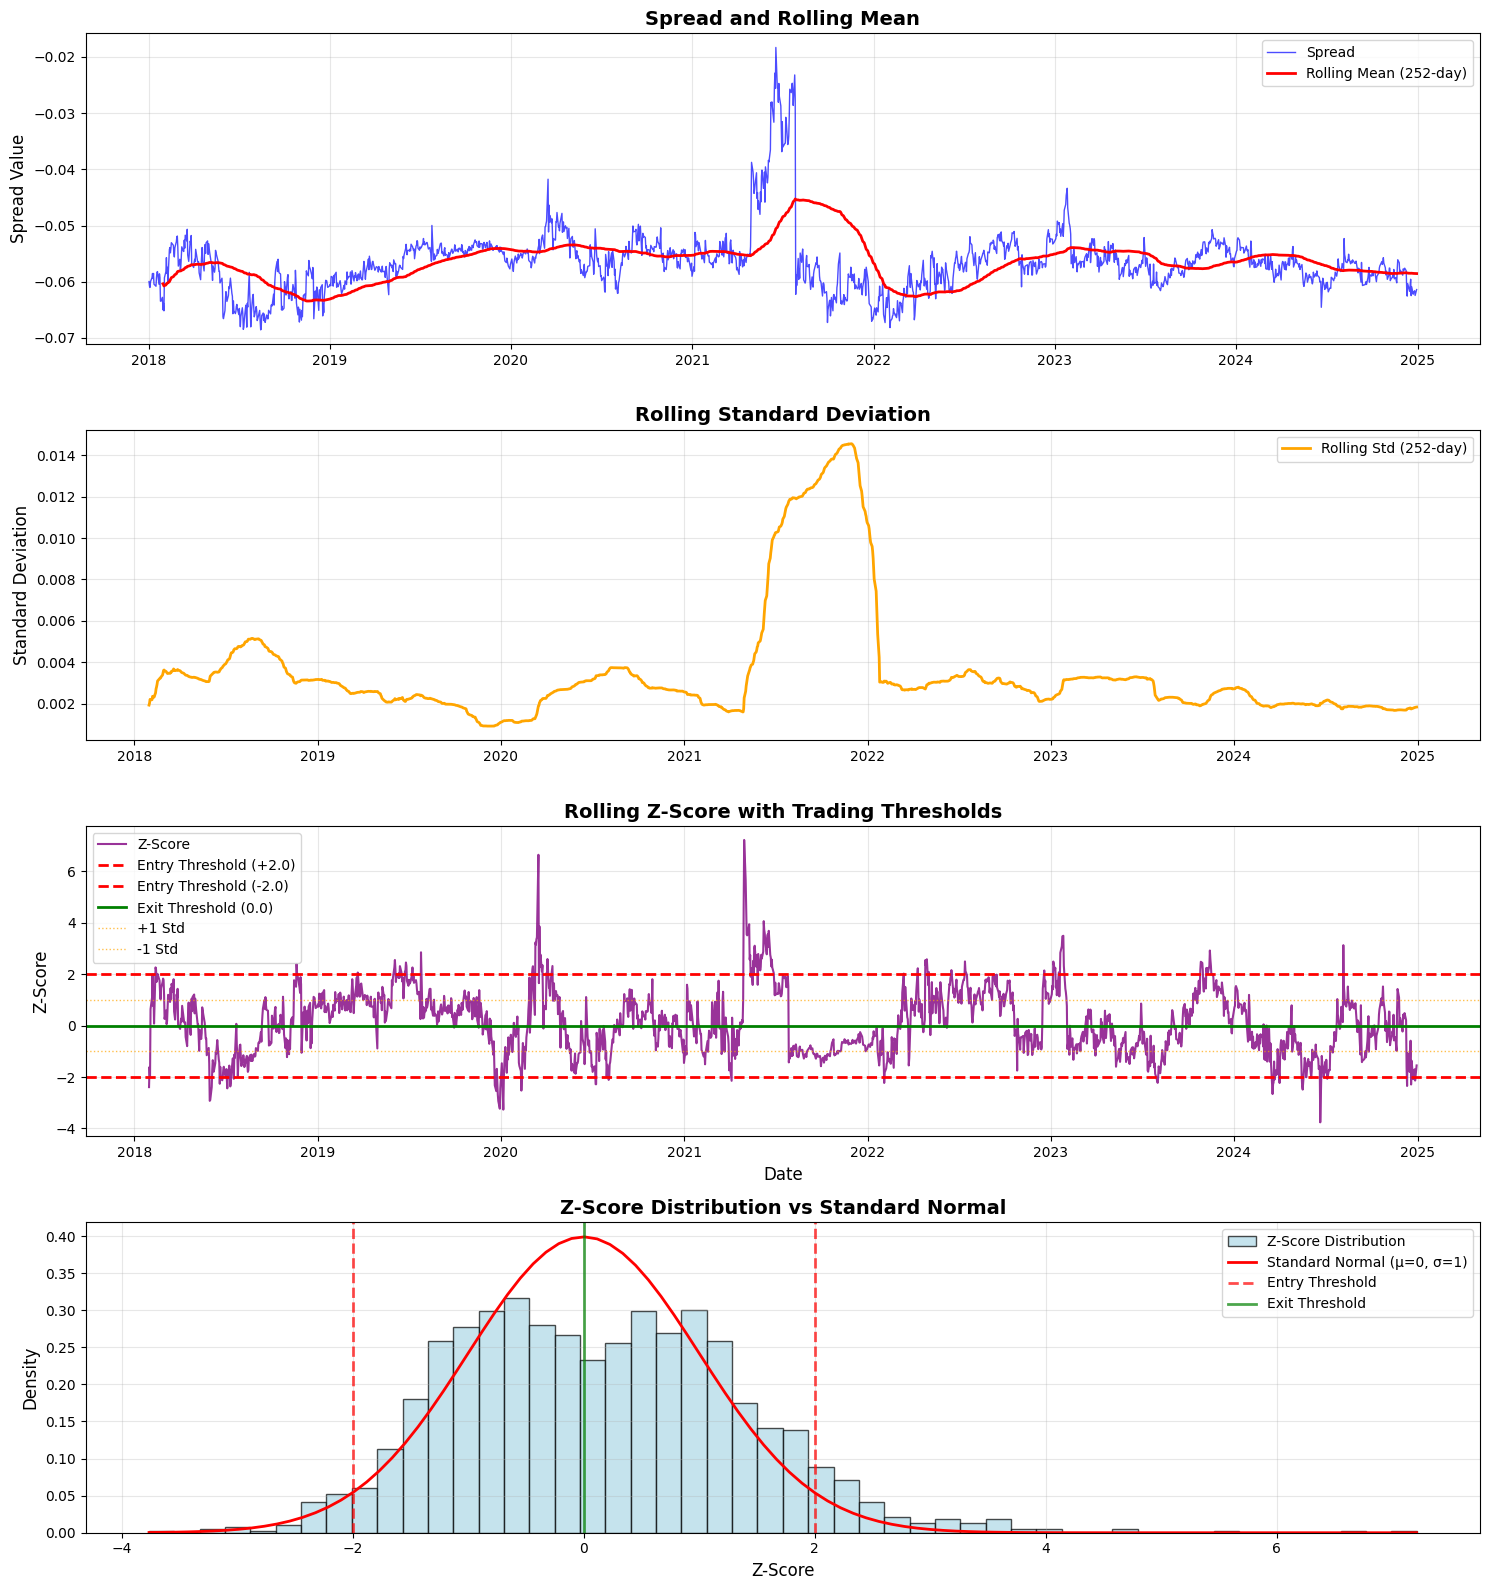


Z-Score Distribution Analysis:
Statistic                 Value          
----------------------------------------
Valid Z-scores            1741           
Mean (should be ~0)       0.125850       
Std Dev (should be ~1)    1.245077       
Skewness                  0.463651       
Kurtosis                  0.898975       

Trading Signal Analysis:
  Z > +2.0 (Short spread): 107 occurrences (6.15%)
  Z < -2.0 (Long spread): 49 occurrences (2.81%)
  Total entry signals: 156 (8.96%)
  Expected frequency (normal): 79 occurrences (4.55%)


In [583]:
# Visualize rolling Z-score results
if 'zscore_results' in locals() and 'validation_results' in locals():
    print("VISUALIZING ROLLING Z-SCORE RESULTS")
    print("=" * 80)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(4, 1, figsize=(15, 16))
    
    # Get valid data for plotting
    valid_mask = zscore_results['zscore'].notna()
    valid_dates = zscore_results.index[valid_mask]
    valid_zscore = zscore_results['zscore'][valid_mask]
    valid_spread = zscore_results['spread'][valid_mask]
    valid_rolling_mean = zscore_results['rolling_mean'][valid_mask]
    
    # Plot 1: Original spread with rolling mean
    axes[0].plot(zscore_results.index, zscore_results['spread'], linewidth=1, alpha=0.7, color='blue', label='Spread')
    axes[0].plot(zscore_results.index, zscore_results['rolling_mean'], linewidth=2, color='red', label='Rolling Mean (252-day)')
    axes[0].set_title('Spread and Rolling Mean', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Spread Value', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Rolling standard deviation
    axes[1].plot(zscore_results.index, zscore_results['rolling_std'], linewidth=2, color='orange', label='Rolling Std (252-day)')
    axes[1].set_title('Rolling Standard Deviation', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Standard Deviation', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Z-score time series with threshold lines
    axes[2].plot(valid_dates, valid_zscore, linewidth=1.5, color='purple', alpha=0.8, label='Z-Score')
    axes[2].axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Entry Threshold (+2.0)')
    axes[2].axhline(y=-2.0, color='red', linestyle='--', linewidth=2, label='Entry Threshold (-2.0)')
    axes[2].axhline(y=0.0, color='green', linestyle='-', linewidth=2, label='Exit Threshold (0.0)')
    axes[2].axhline(y=1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='+1 Std')
    axes[2].axhline(y=-1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='-1 Std')
    axes[2].set_title('Rolling Z-Score with Trading Thresholds', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Z-Score', fontsize=12)
    axes[2].set_xlabel('Date', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Plot 4: Z-score histogram with normal distribution
    valid_zscore_clean = valid_zscore.dropna()
    axes[3].hist(valid_zscore_clean, bins=50, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Z-Score Distribution')
    
    # Overlay standard normal distribution
    from scipy import stats
    x = np.linspace(valid_zscore_clean.min(), valid_zscore_clean.max(), 100)
    normal_dist = stats.norm.pdf(x, 0, 1)  # Standard normal
    axes[3].plot(x, normal_dist, 'r-', linewidth=2, label='Standard Normal (μ=0, σ=1)')
    
    # Add threshold lines
    axes[3].axvline(x=2.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Entry Threshold')
    axes[3].axvline(x=-2.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    axes[3].axvline(x=0.0, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Exit Threshold')
    
    axes[3].set_title('Z-Score Distribution vs Standard Normal', fontsize=14, fontweight='bold')
    axes[3].set_xlabel('Z-Score', fontsize=12)
    axes[3].set_ylabel('Density', fontsize=12)
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional analysis
    print(f"\nZ-Score Distribution Analysis:")
    print(f"{'Statistic':<25} {'Value':<15}")
    print("-" * 40)
    print(f"{'Valid Z-scores':<25} {len(valid_zscore_clean):<15}")
    print(f"{'Mean (should be ~0)':<25} {valid_zscore_clean.mean():<15.6f}")
    print(f"{'Std Dev (should be ~1)':<25} {valid_zscore_clean.std():<15.6f}")
    print(f"{'Skewness':<25} {valid_zscore_clean.skew():<15.6f}")
    print(f"{'Kurtosis':<25} {valid_zscore_clean.kurtosis():<15.6f}")
    
    # Threshold analysis
    above_threshold = (valid_zscore_clean > 2.0).sum()
    below_threshold = (valid_zscore_clean < -2.0).sum()
    total_valid = len(valid_zscore_clean)
    
    print(f"\nTrading Signal Analysis:")
    print(f"  Z > +2.0 (Short spread): {above_threshold} occurrences ({above_threshold/total_valid*100:.2f}%)")
    print(f"  Z < -2.0 (Long spread): {below_threshold} occurrences ({below_threshold/total_valid*100:.2f}%)")
    print(f"  Total entry signals: {above_threshold + below_threshold} ({(above_threshold + below_threshold)/total_valid*100:.2f}%)")
    print(f"  Expected frequency (normal): {total_valid * 0.0455:.0f} occurrences (4.55%)")
    
else:
    print("❌ Z-score results not available - please run previous cells first")

In [584]:
def test_different_zscore_parameters(spread, windows=[126, 252, 504], min_periods_list=[10, 20, 40]):
    """
    Test Z-score calculation with different parameters to find optimal settings.
    
    Parameters:
    -----------
    spread : pd.Series
        Spread series to calculate Z-scores for
    windows : list, default [126, 252, 504]
        List of rolling window sizes to test (6 months, 1 year, 2 years)
    min_periods_list : list, default [10, 20, 40]
        List of minimum periods to test
        
    Returns:
    --------
    pd.DataFrame
        Comparison of Z-score statistics across different parameters
    """
    print("TESTING DIFFERENT Z-SCORE PARAMETERS")
    print("=" * 80)
    
    parameter_results = []
    
    for window in windows:
        for min_periods in min_periods_list:
            print(f"\nTesting: window={window}, min_periods={min_periods}")
            
            # Calculate Z-scores with these parameters
            zscore_data = calculate_rolling_zscore(spread, window=window, min_periods=min_periods)
            zscore = zscore_data['zscore']
            
            # Calculate statistics
            valid_mask = zscore.notna()
            valid_count = valid_mask.sum()
            total_count = len(zscore)
            valid_percentage = valid_count / total_count * 100
            
            if valid_count > 0:
                valid_zscore = zscore[valid_mask]
                
                # Calculate signal frequency
                entry_signals = (abs(valid_zscore) > 2.0).sum()
                entry_frequency = entry_signals / valid_count * 100
                
                # Calculate extreme value frequency
                extreme_signals = (abs(valid_zscore) > 5.0).sum()
                extreme_frequency = extreme_signals / valid_count * 100
                
                result = {
                    'window': window,
                    'min_periods': min_periods,
                    'valid_count': valid_count,
                    'valid_percentage': valid_percentage,
                    'zscore_mean': valid_zscore.mean(),
                    'zscore_std': valid_zscore.std(),
                    'zscore_min': valid_zscore.min(),
                    'zscore_max': valid_zscore.max(),
                    'entry_signals': entry_signals,
                    'entry_frequency': entry_frequency,
                    'extreme_signals': extreme_signals,
                    'extreme_frequency': extreme_frequency
                }
                
                parameter_results.append(result)
                
                print(f"  Valid data: {valid_count}/{total_count} ({valid_percentage:.1f}%)")
                print(f"  Z-score stats: mean={valid_zscore.mean():.3f}, std={valid_zscore.std():.3f}")
                print(f"  Entry signals: {entry_signals} ({entry_frequency:.2f}%)")
                print(f"  Extreme signals: {extreme_signals} ({extreme_frequency:.2f}%)")
            else:
                print(f"  ❌ No valid Z-scores calculated")
    
    # Convert to DataFrame for easy comparison
    if parameter_results:
        results_df = pd.DataFrame(parameter_results)
        
        print(f"\nPARAMETER COMPARISON SUMMARY")
        print("-" * 120)
        print(f"{'Window':<8} {'Min_Per':<8} {'Valid%':<8} {'Z_Mean':<8} {'Z_Std':<8} {'Entry%':<8} {'Extreme%':<9} {'Range':<12}")
        print("-" * 120)
        
        for _, row in results_df.iterrows():
            range_val = row['zscore_max'] - row['zscore_min']
            print(f"{row['window']:<8} {row['min_periods']:<8} {row['valid_percentage']:<8.1f} "
                  f"{row['zscore_mean']:<8.3f} {row['zscore_std']:<8.3f} {row['entry_frequency']:<8.2f} "
                  f"{row['extreme_frequency']:<9.2f} {range_val:<12.3f}")
        
        print("-" * 120)
        
        # Recommendations
        print(f"\nPARAMETER RECOMMENDATIONS:")
        
        # Find best parameters based on criteria
        sufficient_data = results_df[results_df['valid_percentage'] > 70]
        if len(sufficient_data) > 0:
            best_coverage = sufficient_data.loc[sufficient_data['valid_percentage'].idxmax()]
            print(f"  📊 Best data coverage: window={best_coverage['window']}, min_periods={best_coverage['min_periods']} "
                  f"({best_coverage['valid_percentage']:.1f}% valid)")
        
        # Find parameters with reasonable signal frequency (2-10%)
        reasonable_signals = results_df[(results_df['entry_frequency'] >= 2) & (results_df['entry_frequency'] <= 10)]
        if len(reasonable_signals) > 0:
            best_signals = reasonable_signals.loc[reasonable_signals['entry_frequency'].idxmin()]
            print(f"  🎯 Best signal frequency: window={best_signals['window']}, min_periods={best_signals['min_periods']} "
                  f"({best_signals['entry_frequency']:.2f}% entry signals)")
        
        # Find parameters with stable Z-scores (std close to 1)
        stable_zscore = results_df[(results_df['zscore_std'] >= 0.8) & (results_df['zscore_std'] <= 1.2)]
        if len(stable_zscore) > 0:
            best_stable = stable_zscore.loc[(stable_zscore['zscore_std'] - 1.0).abs().idxmin()]
            print(f"  ⚖️  Most stable Z-scores: window={best_stable['window']}, min_periods={best_stable['min_periods']} "
                  f"(std={best_stable['zscore_std']:.3f})")
        
        return results_df
    else:
        print("❌ No valid parameter combinations found")
        return None

# Test different Z-score parameters
if 'spread' in locals():
    parameter_comparison = test_different_zscore_parameters(spread)
else:
    print("❌ Spread not available - please run previous cells first")

TESTING DIFFERENT Z-SCORE PARAMETERS

Testing: window=126, min_periods=10
Calculating rolling Z-scores with window=126, min_periods=10...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 1751 / 1760 (99.5%)
Z-score range: [-3.762, 7.210]
Z-score mean: 0.123
Z-score std: 1.247
  Valid data: 1751/1760 (99.5%)
  Z-score stats: mean=0.123, std=1.247
  Entry signals: 158 (9.02%)
  Extreme signals: 3 (0.17%)

Testing: window=126, min_periods=20
Calculating rolling Z-scores with window=126, min_periods=20...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 1741 / 1760 (98.9%)
Z-score range: [-3.762, 7.210]
Z-score mean: 0.126
Z-score std: 1.245
  Valid data: 1741/1760 (98.9%)
  Z-score stats: mean=0.126, std=1.245
  Entry signals: 156 (8.96%)
  Extreme signals: 3 (0.17%)

Testing: window=126, min_periods=40
Calculating rolling Z-scores with window=126, min_periods=40...
✅ Rolling Z-score calculation completed!
Valid Z-scores: 1721 / 1760 (97.8%)
Z-score range: [-3.762, 7.210]


### 3.2 Implement Signal Logic

Now we'll implement the trading signal logic based on the Z-scores we calculated. The strategy follows a mean reversion approach:

**Trading Rules:**
- **Entry Long Spread**: Z-score < -2.0 (spread is too low) → Long SYMBOL1, Short SYMBOL2
- **Entry Short Spread**: Z-score > 2.0 (spread is too high) → Short SYMBOL1, Long SYMBOL2  
- **Exit**: Z-score crosses 0 (spread reverts to mean) → Close positions

**Position Sizing Options:**
1. **Fixed Allocation**: Equal dollar allocation to each leg
2. **Volatility-Based**: Scale positions by inverse volatility

In [585]:
def generate_trading_signals(zscore_results, entry_threshold=2.0, exit_threshold=0.0):
    """
    Generate trading signals based on Z-score thresholds.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        DataFrame containing Z-scores from calculate_rolling_zscore
    entry_threshold : float, default 2.0
        Z-score threshold for entry signals
    exit_threshold : float, default 0.0
        Z-score threshold for exit signals (mean reversion)
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with trading signals and positions
    """
    print(f"GENERATING TRADING SIGNALS")
    print(f"Entry threshold: ±{entry_threshold}, Exit threshold: {exit_threshold}")
    print("=" * 60)
    
    # Create a copy to avoid modifying original data
    signals = zscore_results.copy()
    
    # Ensure index is timezone-naive for consistency
    if hasattr(signals.index, 'tz') and signals.index.tz is not None:
        signals.index = signals.index.tz_localize(None)
    
    # Initialize signal columns with proper dtypes
    signals['signal'] = 0  # 0: no signal, 1: long spread, -1: short spread
    signals['position'] = 0  # Current position (same encoding as signal)
    signals['entry_date'] = pd.NaT
    signals['exit_date'] = pd.NaT
    signals['hold_period'] = 0  # Days in position
    
    # Get valid Z-scores
    valid_mask = signals['zscore'].notna()
    valid_dates = signals.index[valid_mask]
    valid_zscore = signals.loc[valid_mask, 'zscore']
    
    if len(valid_zscore) == 0:
        print("❌ No valid Z-scores found for signal generation")
        return signals
    
    # Generate entry signals
    print("Generating entry signals...")
    
    # Long spread signal: Z-score < -entry_threshold
    long_signals = valid_zscore < -entry_threshold
    signals.loc[valid_mask & long_signals, 'signal'] = 1
    
    # Short spread signal: Z-score > entry_threshold  
    short_signals = valid_zscore > entry_threshold
    signals.loc[valid_mask & short_signals, 'signal'] = -1
    
    # Track positions and exits
    current_position = 0
    entry_date_idx = None
    
    print("Processing position logic...")
    
    for i, date in enumerate(valid_dates):
        current_signal = signals.loc[date, 'signal']
        current_zscore = signals.loc[date, 'zscore']
        
        # Check for exit signal (crossing 0)
        if current_position != 0:
            # Exit when Z-score crosses 0 in the direction of mean reversion
            if (current_position == 1 and current_zscore >= exit_threshold) or \
               (current_position == -1 and current_zscore <= exit_threshold):
                signals.loc[date, 'position'] = 0  # Exit
                # Use .value to ensure timezone-naive datetime
                signals.at[date, 'exit_date'] = pd.Timestamp(date)
                
                # Calculate hold period
                if entry_date_idx is not None:
                    hold_days = (date - valid_dates[entry_date_idx]).days
                    signals.at[date, 'hold_period'] = hold_days
                
                current_position = 0
                entry_date_idx = None
            else:
                # Maintain current position
                signals.loc[date, 'position'] = current_position
                
                # Update hold period
                if entry_date_idx is not None:
                    hold_days = (date - valid_dates[entry_date_idx]).days
                    signals.at[date, 'hold_period'] = hold_days
        else:
            # Check for entry signal
            if current_signal != 0:
                signals.loc[date, 'position'] = current_signal
                # Use .at and pd.Timestamp to ensure timezone-naive datetime
                signals.at[date, 'entry_date'] = pd.Timestamp(date)
                current_position = current_signal
                entry_date_idx = i
    
    # Signal statistics
    total_periods = len(signals)
    entry_signals = (signals['signal'] != 0).sum()
    long_entries = (signals['signal'] == 1).sum()
    short_entries = (signals['signal'] == -1).sum()
    exits = signals['exit_date'].notna().sum()
    
    print(f"\nSIGNAL GENERATION RESULTS:")
    print(f"Total periods: {total_periods}")
    print(f"Entry signals: {entry_signals} ({entry_signals/total_periods*100:.2f}%)")
    print(f"  Long spread entries: {long_entries} ({long_entries/total_periods*100:.2f}%)")
    print(f"  Short spread entries: {short_entries} ({short_entries/total_periods*100:.2f}%)")
    print(f"Exit signals: {exits}")
    
    # Position statistics
    positions = signals['position'] != 0
    position_periods = positions.sum()
    max_hold_period = signals['hold_period'].max()
    avg_hold_period = signals.loc[signals['hold_period'] > 0, 'hold_period'].mean()
    
    print(f"\nPOSITION STATISTICS:")
    print(f"Periods in position: {position_periods} ({position_periods/total_periods*100:.2f}%)")
    print(f"Max hold period: {max_hold_period} days")
    print(f"Avg hold period: {avg_hold_period:.1f} days" if not pd.isna(avg_hold_period) else "Avg hold period: N/A")
    
    return signals

# Generate trading signals
if 'zscore_results' in locals():
    trading_signals = generate_trading_signals(zscore_results, entry_threshold=1.5, exit_threshold=0.0)
    
    # Display first few signals
    print(f"\nFirst 10 trading signals:")
    display_cols = ['zscore', 'signal', 'position', 'entry_date', 'exit_date', 'hold_period']
    print(trading_signals[display_cols].head(10))
    
    # Display last few signals  
    print(f"\nLast 10 trading signals:")
    print(trading_signals[display_cols].tail(10))
else:
    print("❌ Z-score results not available - please run previous cells first")

GENERATING TRADING SIGNALS
Entry threshold: ±1.5, Exit threshold: 0.0
Generating entry signals...
Processing position logic...

SIGNAL GENERATION RESULTS:
Total periods: 1760
Entry signals: 356 (20.23%)
  Long spread entries: 129 (7.33%)
  Short spread entries: 227 (12.90%)
Exit signals: 38

POSITION STATISTICS:
Periods in position: 963 (54.72%)
Max hold period: 154 days
Avg hold period: 38.6 days

First 10 trading signals:
            zscore  signal  position entry_date exit_date  hold_period
date                                                                  
2018-01-02     NaN       0         0        NaT       NaT            0
2018-01-03     NaN       0         0        NaT       NaT            0
2018-01-04     NaN       0         0        NaT       NaT            0
2018-01-05     NaN       0         0        NaT       NaT            0
2018-01-08     NaN       0         0        NaT       NaT            0
2018-01-09     NaN       0         0        NaT       NaT            0
2018

In [586]:
def calculate_position_sizes(signals, prices_data, method='fixed', total_capital=100000):
    """
    Calculate position sizes for each leg of the spread trade.
    
    Parameters:
    -----------
    signals : pd.DataFrame  
        DataFrame with trading signals and positions
    prices_data : pd.DataFrame
        DataFrame with price data for SYMBOL1 and SYMBOL2
    method : str, default 'fixed'
        Position sizing method: 'fixed' or 'volatility_based'
    total_capital : float, default 100000
        Total capital to allocate
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with position sizes and dollar allocations
    """
    print("=" * 60)
    print(f"*Method: {method}, Total Capital: ${total_capital:,.0f}")
    
    # Create result dataframe
    positions = signals.copy()
    
    # Initialize position size columns
    positions[f'{SYMBOL1}_shares'] = 0.0
    positions[f'{SYMBOL2}_shares'] = 0.0  
    positions[f'{SYMBOL1}_dollars'] = 0.0
    positions[f'{SYMBOL2}_dollars'] = 0.0
    positions['total_exposure'] = 0.0
    
    # Get price data
    if SYMBOL1 not in prices_data.columns or SYMBOL2 not in prices_data.columns:
        print(f"❌ Price data must contain '{SYMBOL1}' and '{SYMBOL2}' columns")
        return positions
    
    # Ensure prices_data index is timezone-naive to match positions index
    if hasattr(prices_data.index, 'tz') and prices_data.index.tz is not None:
        prices_data = prices_data.copy()
        prices_data.index = prices_data.index.tz_localize(None)
        
    # Align price data with signals
    common_dates = positions.index.intersection(prices_data.index)
    positions = positions.loc[common_dates]
    aligned_prices = prices_data.loc[common_dates]
    
    if method == 'fixed':
        # Fixed allocation: 50% capital to each leg when in position
        capital_per_leg = total_capital * 0.5
        
        for date in positions.index:
            position = positions.loc[date, 'position']
            price1 = aligned_prices.loc[date, SYMBOL1]
            price2 = aligned_prices.loc[date, SYMBOL2]
            
            if position == 1:  # Long spread: Long SYMBOL1, Short SYMBOL2
                positions.loc[date, f'{SYMBOL1}_shares'] = capital_per_leg / price1
                positions.loc[date, f'{SYMBOL1}_dollars'] = capital_per_leg
                positions.loc[date, f'{SYMBOL2}_shares'] = -capital_per_leg / price2  # Short
                positions.loc[date, f'{SYMBOL2}_dollars'] = -capital_per_leg
                positions.loc[date, 'total_exposure'] = capital_per_leg + capital_per_leg
                
            elif position == -1:  # Short spread: Short SYMBOL1, Long SYMBOL2
                positions.loc[date, f'{SYMBOL1}_shares'] = -capital_per_leg / price1  # Short
                positions.loc[date, f'{SYMBOL1}_dollars'] = -capital_per_leg
                positions.loc[date, f'{SYMBOL2}_shares'] = capital_per_leg / price2
                positions.loc[date, f'{SYMBOL2}_dollars'] = capital_per_leg  
                positions.loc[date, 'total_exposure'] = capital_per_leg + capital_per_leg
                
            # position == 0: No position (all zeros)
    
    elif method == 'volatility_based':        
        # Calculate rolling volatility (20-day)
        returns = aligned_prices.pct_change()
        rolling_vol = returns.rolling(window=20).std() * np.sqrt(252)  # Annualized
        
        # Inverse volatility weights
        for date in positions.index:
            position = positions.loc[date, 'position']
            price1 = aligned_prices.loc[date, SYMBOL1]
            price2 = aligned_prices.loc[date, SYMBOL2]
            
            if position != 0:
                # Get volatilities (use last available if current is NaN)
                vol1 = rolling_vol.loc[:date, SYMBOL1].dropna().iloc[-1] if not rolling_vol.loc[:date, SYMBOL1].dropna().empty else 0.2
                vol2 = rolling_vol.loc[:date, SYMBOL2].dropna().iloc[-1] if not rolling_vol.loc[:date, SYMBOL2].dropna().empty else 0.2
                
                # Inverse volatility weights
                inv_vol1 = 1 / vol1 if vol1 > 0 else 1
                inv_vol2 = 1 / vol2 if vol2 > 0 else 1
                total_inv_vol = inv_vol1 + inv_vol2
                
                weight1 = inv_vol1 / total_inv_vol
                weight2 = inv_vol2 / total_inv_vol
                
                capital1 = total_capital * weight1
                capital2 = total_capital * weight2
                
                if position == 1:  # Long spread: Long SYMBOL1, Short SYMBOL2
                    positions.loc[date, f'{SYMBOL1}_shares'] = capital1 / price1
                    positions.loc[date, f'{SYMBOL1}_dollars'] = capital1
                    positions.loc[date, f'{SYMBOL2}_shares'] = -capital2 / price2  # Short
                    positions.loc[date, f'{SYMBOL2}_dollars'] = -capital2
                    positions.loc[date, 'total_exposure'] = capital1 + capital2
                    
                elif position == -1:  # Short spread: Short SYMBOL1, Long SYMBOL2
                    positions.loc[date, f'{SYMBOL1}_shares'] = -capital1 / price1  # Short
                    positions.loc[date, f'{SYMBOL1}_dollars'] = -capital1
                    positions.loc[date, f'{SYMBOL2}_shares'] = capital2 / price2
                    positions.loc[date, f'{SYMBOL2}_dollars'] = capital2
                    positions.loc[date, 'total_exposure'] = capital1 + capital2
    
    else:
        print(f"❌ Unknown position sizing method: {method}")
        return positions
    
    # Position statistics
    active_positions = positions['position'] != 0
    periods_in_position = active_positions.sum()
    
    if periods_in_position > 0:
        avg_sym1_exposure = positions.loc[active_positions, f'{SYMBOL1}_dollars'].abs().mean()
        avg_sym2_exposure = positions.loc[active_positions, f'{SYMBOL2}_dollars'].abs().mean()
        avg_total_exposure = positions.loc[active_positions, 'total_exposure'].mean()
        
        print(f" POSITION SIZING RESULTS:")
        print(f"Periods in position: {periods_in_position}")
        print(f"Average {SYMBOL1} exposure: ${avg_sym1_exposure:,.0f}")
        print(f"Average {SYMBOL2} exposure: ${avg_sym2_exposure:,.0f}")
        print(f"Average total exposure: ${avg_total_exposure:,.0f}")
        
        # Show sample positions
        # print(f"\nSample positions:")
        # sample_cols = ['position', 'goog_shares', 'googl_shares', 'goog_dollars', 'googl_dollars', 'total_exposure']
        # sample_positions = positions[active_positions][sample_cols].head(5)
        # print(sample_positions)
    
    return positions

# Calculate position sizes (using price data from earlier cells)
if 'trading_signals' in locals() and 'close_prices' in locals():
    print(f"CALCULATING POSITION SIZES")
    # Fixed allocation
    fixed_positions = calculate_position_sizes(trading_signals, close_prices, method='fixed', total_capital=TOTAL_CAPITAL)
    
    # Volatility-based allocation  
    vol_positions = calculate_position_sizes(trading_signals, close_prices, method='volatility_based', total_capital=TOTAL_CAPITAL)
    
    print(f"\nComparison of position sizing methods:")
    print(f"Fixed allocation periods in position: {(fixed_positions['position'] != 0).sum()}")
    print(f"Volatility-based periods in position: {(vol_positions['position'] != 0).sum()}")
    
else:
    print("❌ Required data not available - please run previous cells first")

CALCULATING POSITION SIZES
*Method: fixed, Total Capital: $100,000
 POSITION SIZING RESULTS:
Periods in position: 963
Average GOOG exposure: $50,000
Average GOOGL exposure: $50,000
Average total exposure: $100,000
*Method: volatility_based, Total Capital: $100,000
 POSITION SIZING RESULTS:
Periods in position: 963
Average GOOG exposure: $50,145
Average GOOGL exposure: $49,855
Average total exposure: $100,000

Comparison of position sizing methods:
Fixed allocation periods in position: 963
Volatility-based periods in position: 963


In [587]:
def analyze_signal_performance(signals, positions, prices_data):
    """
    Analyze the performance of trading signals.
    
    Parameters:
    -----------
    signals : pd.DataFrame
        DataFrame with trading signals
    positions : pd.DataFrame  
        DataFrame with position sizes
    prices_data : pd.DataFrame
        DataFrame with price data for SYMBOL1 and SYMBOL2
        
    Returns:
    --------
    dict
        Performance statistics and analysis
    """
    print("ANALYZING SIGNAL PERFORMANCE")
    print("=" * 60)
    
    # Ensure all dataframes have timezone-naive indices
    def make_timezone_naive(df):
        if hasattr(df.index, 'tz') and df.index.tz is not None:
            df = df.copy()
            df.index = df.index.tz_localize(None)
        return df
    
    signals = make_timezone_naive(signals)
    positions = make_timezone_naive(positions)
    prices_data = make_timezone_naive(prices_data)
    
    # Combine signals and positions
    analysis_data = signals.copy()
    
    # Add position data
    position_cols = [f'{SYMBOL1}_shares', f'{SYMBOL2}_shares', f'{SYMBOL1}_dollars', f'{SYMBOL2}_dollars', 'total_exposure']
    for col in position_cols:
        if col in positions.columns:
            analysis_data[col] = positions[col]
    
    # Add price data
    price_cols = [SYMBOL1, SYMBOL2]
    for col in price_cols:
        if col in prices_data.columns:
            analysis_data[f'{col}_price'] = prices_data[col]
    
    # Calculate daily P&L
    analysis_data[f'{SYMBOL1}_daily_pnl'] = 0.0
    analysis_data[f'{SYMBOL2}_daily_pnl'] = 0.0
    analysis_data['total_daily_pnl'] = 0.0
    analysis_data['cumulative_pnl'] = 0.0
    
    # Get valid dates with all data
    valid_mask = (
        analysis_data[f'{SYMBOL1}_shares'].notna() & 
        analysis_data[f'{SYMBOL2}_shares'].notna() &
        analysis_data[f'{SYMBOL1}_price'].notna() & 
        analysis_data[f'{SYMBOL2}_price'].notna()
    )
    
    valid_data = analysis_data[valid_mask].copy()
    
    if len(valid_data) == 0:
        print("❌ No valid data for performance analysis")
        return {}
    
    # Calculate daily returns and P&L
    valid_data[f'{SYMBOL1}_returns'] = valid_data[f'{SYMBOL1}_price'].pct_change()
    valid_data[f'{SYMBOL2}_returns'] = valid_data[f'{SYMBOL2}_price'].pct_change()
    
    # Daily P&L = position_size * price_return
    valid_data[f'{SYMBOL1}_daily_pnl'] = valid_data[f'{SYMBOL1}_shares'].shift(1) * (valid_data[f'{SYMBOL1}_price'] - valid_data[f'{SYMBOL1}_price'].shift(1))
    valid_data[f'{SYMBOL2}_daily_pnl'] = valid_data[f'{SYMBOL2}_shares'].shift(1) * (valid_data[f'{SYMBOL2}_price'] - valid_data[f'{SYMBOL2}_price'].shift(1))
    valid_data['total_daily_pnl'] = valid_data[f'{SYMBOL1}_daily_pnl'] + valid_data[f'{SYMBOL2}_daily_pnl']
    
    valid_data['total_daily_pnl'] = valid_data['total_daily_pnl'].fillna(0)
    # Cumulative P&L
    valid_data['cumulative_pnl'] = valid_data['total_daily_pnl'].cumsum()
    
    # Trade analysis
    trades = []
    current_trade = None
    
    for i, (date, row) in enumerate(valid_data.iterrows()):
        position = row['position']
        
        # Entry signal
        if position != 0 and (current_trade is None or current_trade['exit_date'] is not None): 
            # New trade starts
            current_trade = {
                'entry_date': pd.Timestamp(date),  # Ensure timezone-naive
                'entry_zscore': row['zscore'],
                'direction': 'long_spread' if position == 1 else 'short_spread',
                f'entry_{SYMBOL1}_price': row[f'{SYMBOL1}_price'],
                f'entry_{SYMBOL2}_price': row[f'{SYMBOL2}_price'],
                'exit_date': None,
                'exit_zscore': None,
                f'exit_{SYMBOL1}_price': None,
                f'exit_{SYMBOL2}_price': None,
                'pnl': 0.0,
                'hold_period': 0,
                f'entry_{SYMBOL1}_shares': row[f'{SYMBOL1}_shares'],
                f'entry_{SYMBOL2}_shares': row[f'{SYMBOL2}_shares'],
                'entry_cum_pnl': row['cumulative_pnl']
            }
        
        # Exit signal
        elif position == 0 and current_trade is not None and current_trade['exit_date'] is None:
            # Trade ends
            current_trade['exit_date'] = pd.Timestamp(date)  # Ensure timezone-naive
            current_trade['exit_zscore'] = row['zscore']
            current_trade[f'exit_{SYMBOL1}_price'] = row[f'{SYMBOL1}_price']
            current_trade[f'exit_{SYMBOL2}_price'] = row[f'{SYMBOL2}_price']
            current_trade['hold_period'] = (date - current_trade['entry_date']).days
            
            # Calculate trade P&L (using cumulative P&L at exit)
            current_trade['pnl'] = row['cumulative_pnl'] - current_trade['entry_cum_pnl']
            
            # Add to completed trades
            trades.append(current_trade.copy())
            current_trade['exit_date'] = pd.Timestamp(date)  # Mark as completed
    
    # Convert trades to DataFrame
    if trades:
        trades_df = pd.DataFrame(trades)
        
        # Trade statistics
        total_trades = len(trades_df)
        winning_trades = (trades_df['pnl'] > 0).sum()
        losing_trades = (trades_df['pnl'] <= 0).sum()
        win_rate = winning_trades / total_trades * 100 if total_trades > 0 else 0
        
        total_pnl = trades_df['pnl'].sum()
        avg_trade_pnl = trades_df['pnl'].mean()
        avg_win = trades_df[trades_df['pnl'] > 0]['pnl'].mean() if winning_trades > 0 else 0
        avg_loss = trades_df[trades_df['pnl'] <= 0]['pnl'].mean() if losing_trades > 0 else 0
        
        avg_hold_period = trades_df['hold_period'].mean()
        
        print(f"TRADE PERFORMANCE RESULTS:")
        print(f"Total trades: {total_trades}")
        print(f"Winning trades: {winning_trades} ({win_rate:.1f}%)")
        print(f"Losing trades: {losing_trades} ({100-win_rate:.1f}%)")
        print(f"Total P&L: ${total_pnl:,.0f}")
        print(f"Average trade P&L: ${avg_trade_pnl:,.0f}")
        print(f"Average win: ${avg_win:,.0f}")
        print(f"Average loss: ${avg_loss:,.0f}")
        print(f"Average hold period: {avg_hold_period:.1f} days")
        
        # Performance by direction
        long_trades = trades_df[trades_df['direction'] == 'long_spread']
        short_trades = trades_df[trades_df['direction'] == 'short_spread']
        
        print(f"\nPERFORMANCE BY DIRECTION:")
        print(f"Long spread trades: {len(long_trades)}")
        if len(long_trades) > 0:
            long_win_rate = (long_trades['pnl'] > 0).sum() / len(long_trades) * 100
            long_avg_pnl = long_trades['pnl'].mean()
            print(f"  Win rate: {long_win_rate:.1f}%, Avg P&L: ${long_avg_pnl:,.0f}")
        
        print(f"Short spread trades: {len(short_trades)}")
        if len(short_trades) > 0:
            short_win_rate = (short_trades['pnl'] > 0).sum() / len(short_trades) * 100
            short_avg_pnl = short_trades['pnl'].mean()
            print(f"  Win rate: {short_win_rate:.1f}%, Avg P&L: ${short_avg_pnl:,.0f}")
        
        # Show sample trades
        print(f"\nSAMPLE TRADES:")
        sample_cols = ['entry_date', 'direction', 'entry_zscore', 'exit_zscore', 'hold_period', 'pnl']
        print(trades_df[sample_cols].head(10))
        
        return {
            'trades_df': trades_df,
            'valid_data': valid_data,
            'total_trades': total_trades,
            'win_rate': win_rate,
            'total_pnl': total_pnl,
            'avg_trade_pnl': avg_trade_pnl,
            'avg_hold_period': avg_hold_period
        }
    
    else:
        print("❌ No completed trades found")
        return {}

# Analyze signal performance
if 'trading_signals' in locals() and 'fixed_positions' in locals() and 'close_prices' in locals():
    performance_results = analyze_signal_performance(trading_signals, fixed_positions, close_prices)
else:
    print("❌ Required data not available for performance analysis")

ANALYZING SIGNAL PERFORMANCE
TRADE PERFORMANCE RESULTS:
Total trades: 38
Winning trades: 37 (97.4%)
Losing trades: 1 (2.6%)
Total P&L: $9,033
Average trade P&L: $238
Average win: $247
Average loss: $-94
Average hold period: 36.5 days

PERFORMANCE BY DIRECTION:
Long spread trades: 17
  Win rate: 100.0%, Avg P&L: $258
Short spread trades: 21
  Win rate: 95.2%, Avg P&L: $222

SAMPLE TRADES:
  entry_date     direction  entry_zscore  exit_zscore  hold_period         pnl
0 2018-01-30   long_spread     -2.393215     0.637029            3  239.154656
1 2018-02-06  short_spread      1.979199    -0.132957           55  112.111647
2 2018-05-31   long_spread     -2.927130     0.066408           53  457.995242
3 2018-07-26   long_spread     -1.958556     0.047587           48  291.134167
4 2018-11-15  short_spread      1.759445    -1.058486           15  400.162173
5 2019-03-11  short_spread      1.800142    -0.562152           49  194.215001
6 2019-05-10  short_spread      1.502918    -0.082561   

### 3.3 Visualize Signals and Performance

Now we'll create comprehensive visualizations of the trading signals and performance metrics as specified in Task 3.3.

#### 3.3.1 Plot Z-score Time Series with Threshold Lines

First, let's create a detailed Z-score visualization with entry/exit points marked.

CREATING Z-SCORE SIGNAL VISUALIZATION


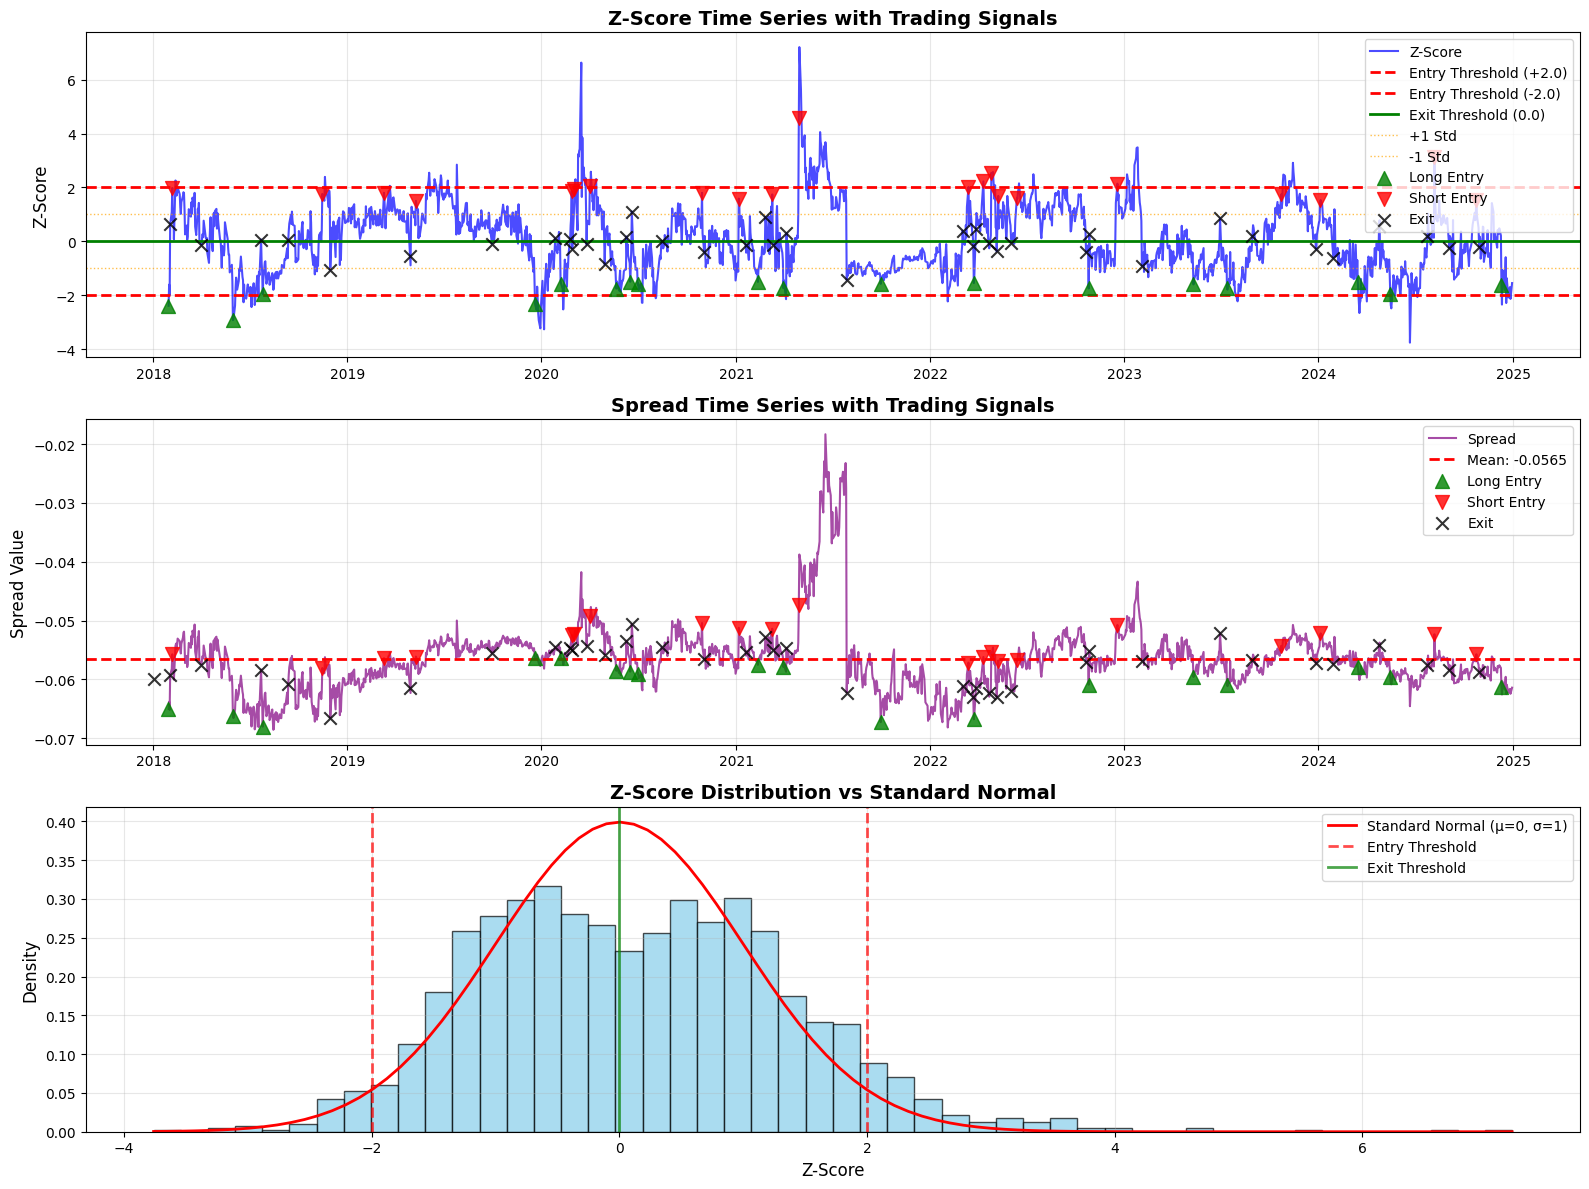


SIGNAL STATISTICS:
--------------------------------------------------
Z-Score Statistics:
  Mean: 0.126
  Std Dev: 1.245
  Range: [-3.762, 7.210]

Trading Signals:
  Total signals: 78
  Entry signals: 39 (Long: 18, Short: 21)
  Exit signals: 39
  Signal frequency: 4.48%

Threshold Analysis:
  Above +2.0: 107 occurrences
  Below -2.0: 49 occurrences
  Total breaches: 156 (8.96%)

Data Coverage: 1741/1760 (98.9%)


In [588]:
def visualize_zscore_signals(zscore_results, trading_signals, entry_threshold=2.0, exit_threshold=0.0):
    """
    Create comprehensive Z-score visualization with trading signals.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    entry_threshold : float, default 2.0
        Z-score threshold for entry signals
    exit_threshold : float, default 0.0
        Z-score threshold for exit signals
        
    Returns:
    --------
    dict
        Dictionary containing visualization data and statistics
    """
    print("CREATING Z-SCORE SIGNAL VISUALIZATION")
    print("=" * 80)
    
    # Extract data
    zscore = zscore_results['zscore']
    spread = zscore_results['spread']
    
    # Get valid data (where Z-score is not NaN)
    valid_mask = zscore.notna()
    valid_dates = zscore.index[valid_mask]
    valid_zscore = zscore[valid_mask]
    valid_spread = spread[valid_mask]
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))
    
    # Plot 1: Z-score time series with signals
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(valid_dates, valid_zscore, linewidth=1.5, color='blue', alpha=0.7, label='Z-Score')
    
    # Add threshold lines
    ax1.axhline(y=entry_threshold, color='red', linestyle='--', linewidth=2, label=f'Entry Threshold (+{entry_threshold})')
    ax1.axhline(y=-entry_threshold, color='red', linestyle='--', linewidth=2, label=f'Entry Threshold (-{entry_threshold})')
    ax1.axhline(y=exit_threshold, color='green', linestyle='-', linewidth=2, label=f'Exit Threshold ({exit_threshold})')
    ax1.axhline(y=1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='+1 Std')
    ax1.axhline(y=-1.0, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='-1 Std')
    
    # Mark entry and exit signals
    if not trading_signals.empty:
        # Entry signals (where position changes from 0 to non-zero)
        position_changes = trading_signals['position'].diff()
        entry_signals_mask = (trading_signals['position'] != 0) & (position_changes != 0)
        entry_dates = trading_signals.index[entry_signals_mask]
        entry_positions = trading_signals.loc[entry_signals_mask, 'position']
        
        # Exit signals (where position changes to 0)
        exit_signals_mask = (trading_signals['position'] == 0) & (position_changes != 0)
        exit_dates = trading_signals.index[exit_signals_mask]
        
        # Get Z-scores for signal dates - use the trading_signals DataFrame which has zscore column
        entry_zscores = trading_signals.loc[entry_signals_mask, 'zscore']
        exit_zscores = trading_signals.loc[exit_signals_mask, 'zscore'] if not exit_dates.empty else pd.Series([], dtype=float)
        
        # Plot entry signals
        long_entries = entry_positions == 1  # Long spread
        short_entries = entry_positions == -1  # Short spread
        
        if long_entries.any():
            long_entry_dates = entry_dates[long_entries]
            long_entry_zscores = entry_zscores[long_entries]
            ax1.scatter(long_entry_dates, long_entry_zscores, 
                      color='green', marker='^', s=100, alpha=0.8, label='Long Entry', zorder=5)
        if short_entries.any():
            short_entry_dates = entry_dates[short_entries]
            short_entry_zscores = entry_zscores[short_entries]
            ax1.scatter(short_entry_dates, short_entry_zscores, 
                      color='red', marker='v', s=100, alpha=0.8, label='Short Entry', zorder=5)
        
        # Plot exit signals
        if not exit_dates.empty:
            ax1.scatter(exit_dates, exit_zscores, color='black', marker='x', s=80, 
                       alpha=0.8, label='Exit', zorder=5)
    
    ax1.set_title('Z-Score Time Series with Trading Signals', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Z-Score', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Spread time series with signal markers
    ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    ax2.plot(valid_dates, valid_spread, linewidth=1.5, color='purple', alpha=0.7, label='Spread')
    ax2.axhline(y=valid_spread.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {valid_spread.mean():.4f}')
    
    # Mark signals on spread chart
    if not trading_signals.empty:
        # Entry signals
        if not entry_dates.empty:
            entry_spreads = trading_signals.loc[entry_signals_mask, 'spread']
            
            if long_entries.any():
                long_entry_dates = entry_dates[long_entries]
                long_entry_spreads = entry_spreads[long_entries]
                ax2.scatter(long_entry_dates, long_entry_spreads, 
                          color='green', marker='^', s=100, alpha=0.8, label='Long Entry', zorder=5)
            if short_entries.any():
                short_entry_dates = entry_dates[short_entries]
                short_entry_spreads = entry_spreads[short_entries]
                ax2.scatter(short_entry_dates, short_entry_spreads, 
                          color='red', marker='v', s=100, alpha=0.8, label='Short Entry', zorder=5)
        
        # Exit signals
        if not exit_dates.empty:
            exit_spreads = trading_signals.loc[exit_signals_mask, 'spread']
            ax2.scatter(exit_dates, exit_spreads, color='black', marker='x', s=80, 
                       alpha=0.8, label='Exit', zorder=5)
    
    ax2.set_title('Spread Time Series with Trading Signals', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Spread Value', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Z-score distribution with thresholds
    ax3 = plt.subplot(3, 1, 3)
    
    # Remove NaN values for histogram
    valid_zscore_clean = valid_zscore.dropna()
    ax3.hist(valid_zscore_clean, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay standard normal distribution
    from scipy import stats
    x = np.linspace(valid_zscore_clean.min(), valid_zscore_clean.max(), 100)
    normal_dist = stats.norm.pdf(x, 0, 1)
    ax3.plot(x, normal_dist, 'r-', linewidth=2, label='Standard Normal (μ=0, σ=1)')
    
    # Add threshold lines
    ax3.axvline(x=entry_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Entry Threshold')
    ax3.axvline(x=-entry_threshold, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.axvline(x=exit_threshold, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Exit Threshold')
    
    ax3.set_title('Z-Score Distribution vs Standard Normal', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Z-Score', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate signal statistics
    signal_stats = calculate_signal_statistics(zscore_results, trading_signals, entry_threshold, exit_threshold)
    
    return {
        'signal_stats': signal_stats,
        'valid_data_points': len(valid_zscore),
        'total_data_points': len(zscore),
        'data_coverage': len(valid_zscore) / len(zscore) * 100
    }

def calculate_signal_statistics(zscore_results, trading_signals, entry_threshold, exit_threshold):
    """
    Calculate comprehensive signal statistics.
    
    Parameters:
    -----------
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    entry_threshold : float
        Z-score threshold for entry signals
    exit_threshold : float
        Z-score threshold for exit signals
        
    Returns:
    --------
    dict
        Dictionary containing signal statistics
    """
    zscore = zscore_results['zscore']
    valid_zscore = zscore.dropna()
    
    # Basic Z-score statistics
    stats_dict = {
        'zscore_mean': valid_zscore.mean(),
        'zscore_std': valid_zscore.std(),
        'zscore_min': valid_zscore.min(),
        'zscore_max': valid_zscore.max(),
        'zscore_range': valid_zscore.max() - valid_zscore.min()
    }
    
    # Signal counts
    if not trading_signals.empty:
        # Count entries (position changes from 0 to non-zero)
        position_changes = trading_signals['position'].diff()
        entry_signals_mask = (trading_signals['position'] != 0) & (position_changes != 0)
        exit_signals_mask = (trading_signals['position'] == 0) & (position_changes != 0)
        
        entry_positions = trading_signals.loc[entry_signals_mask, 'position']
        
        stats_dict.update({
            'total_signals': entry_signals_mask.sum() + exit_signals_mask.sum(),
            'entry_signals': entry_signals_mask.sum(),
            'exit_signals': exit_signals_mask.sum(),
            'long_entries': (entry_positions == 1).sum(),
            'short_entries': (entry_positions == -1).sum()
        })
        
        # Signal frequency
        total_valid = len(valid_zscore)
        if total_valid > 0:
            stats_dict.update({
                'signal_frequency': (entry_signals_mask.sum() + exit_signals_mask.sum()) / total_valid * 100,
                'entry_frequency': entry_signals_mask.sum() / total_valid * 100,
                'exit_frequency': exit_signals_mask.sum() / total_valid * 100
            })
    
    # Threshold analysis
    above_threshold = (valid_zscore > entry_threshold).sum()
    below_threshold = (valid_zscore < -entry_threshold).sum()
    total_valid = len(valid_zscore)
    
    stats_dict.update({
        'above_entry_threshold': above_threshold,
        'below_entry_threshold': below_threshold,
        'total_threshold_breaches': above_threshold + below_threshold,
        'threshold_breach_frequency': (above_threshold + below_threshold) / total_valid * 100 if total_valid > 0 else 0
    })
    
    return stats_dict

# Create Z-score signal visualization
if 'zscore_results' in locals() and 'trading_signals' in locals():
    
    viz_results = visualize_zscore_signals(zscore_results, trading_signals, 
                                         entry_threshold=2.0, exit_threshold=0.0)
    
    # Display signal statistics
    if 'signal_stats' in viz_results:
        stats = viz_results['signal_stats']
        print("\nSIGNAL STATISTICS:")
        print("-" * 50)
        print(f"Z-Score Statistics:")
        print(f"  Mean: {stats['zscore_mean']:.3f}")
        print(f"  Std Dev: {stats['zscore_std']:.3f}")
        print(f"  Range: [{stats['zscore_min']:.3f}, {stats['zscore_max']:.3f}]")
        
        if 'total_signals' in stats:
            print(f"\nTrading Signals:")
            print(f"  Total signals: {stats['total_signals']}")
            print(f"  Entry signals: {stats['entry_signals']} (Long: {stats['long_entries']}, Short: {stats['short_entries']})")
            print(f"  Exit signals: {stats['exit_signals']}")
            print(f"  Signal frequency: {stats['signal_frequency']:.2f}%")
        
        print(f"\nThreshold Analysis:")
        print(f"  Above +{2.0}: {stats['above_entry_threshold']} occurrences")
        print(f"  Below -{2.0}: {stats['below_entry_threshold']} occurrences")
        print(f"  Total breaches: {stats['total_threshold_breaches']} ({stats['threshold_breach_frequency']:.2f}%)")
    
    print(f"\nData Coverage: {viz_results['valid_data_points']}/{viz_results['total_data_points']} ({viz_results['data_coverage']:.1f}%)")
    
else:
    print("❌ Required data not available for visualization")
    print("Please run the Z-score calculation and signal generation cells first.")

#### 3.3.2 Mark Entry/Exit Points on Price Charts

Now let's create visualizations that show the entry and exit points directly on the GOOG and GOOGL price charts.

CREATING PRICE CHART SIGNAL VISUALIZATION


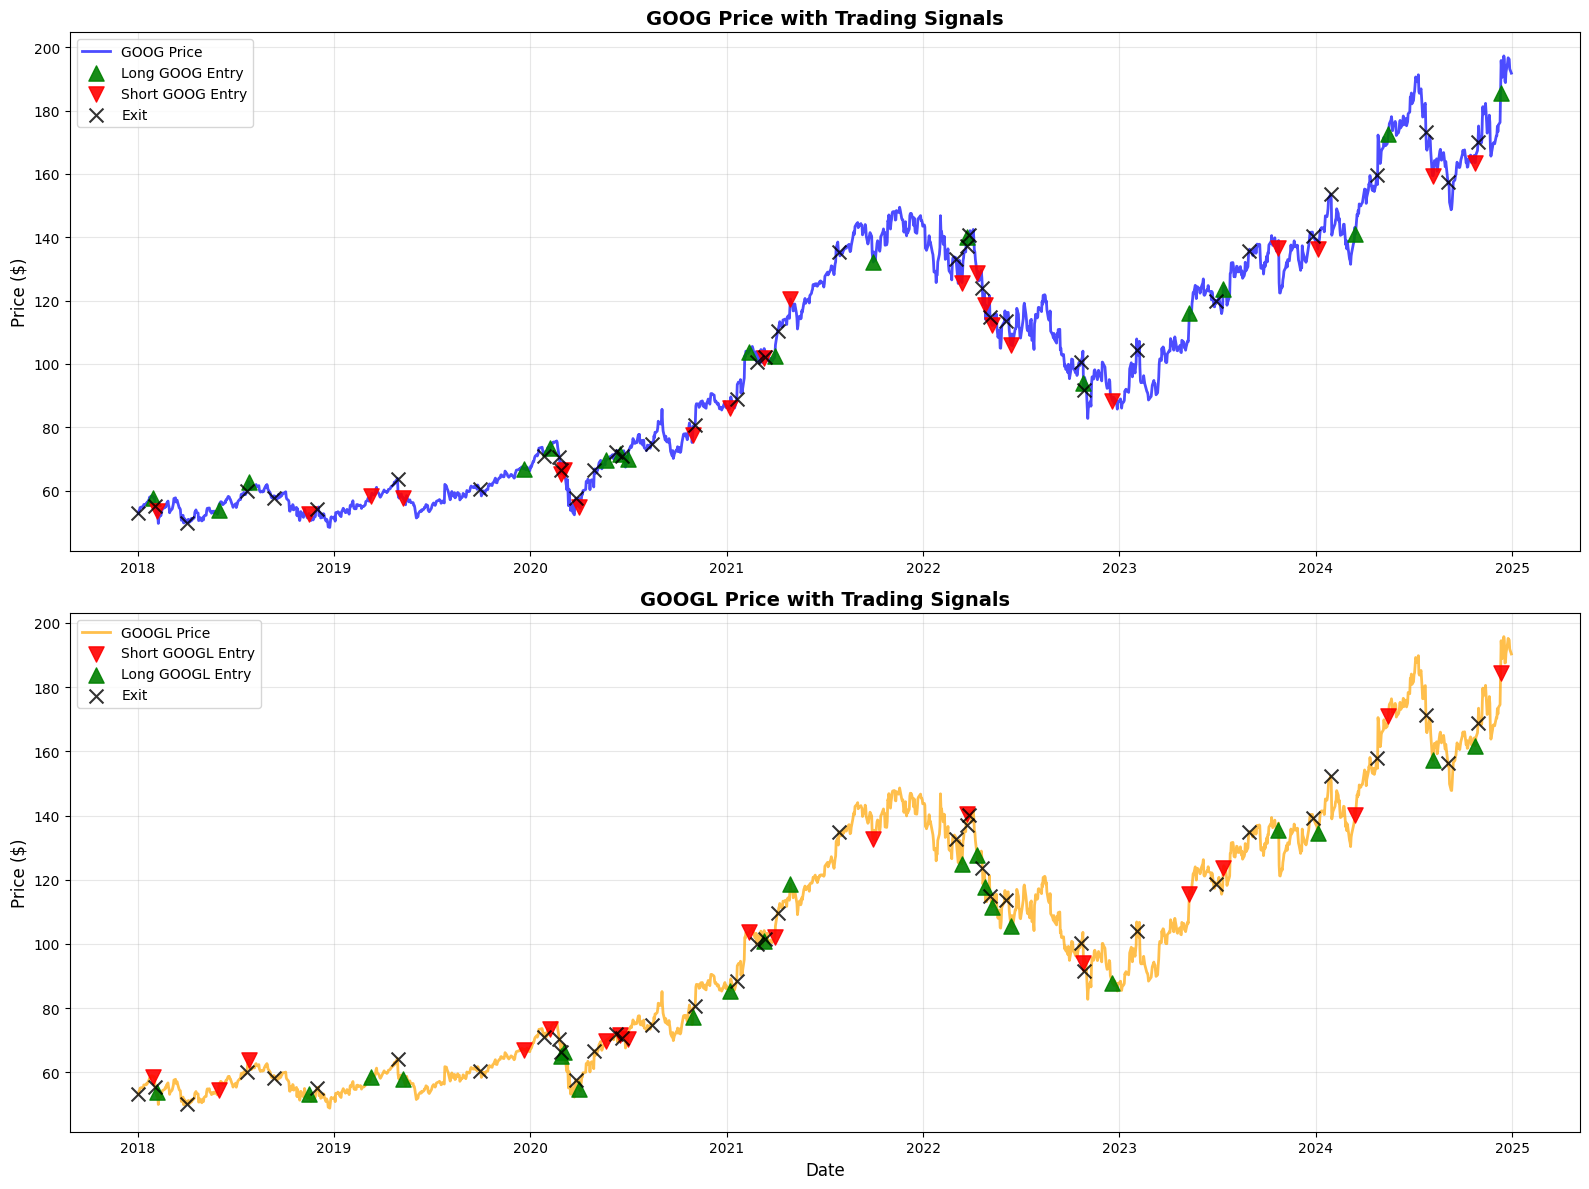

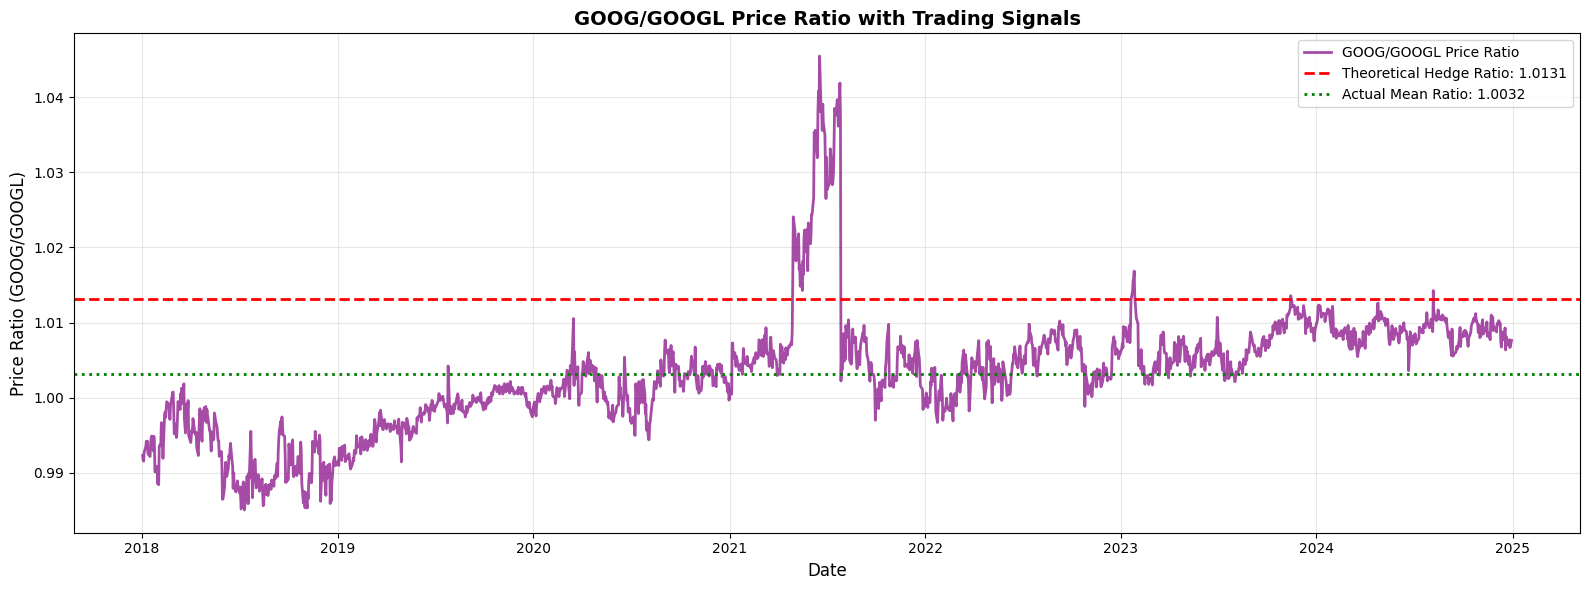


PRICE STATISTICS:
--------------------------------------------------
GOOG Price Statistics:
  Mean: $101.23
  Range: $48.41 - $197.25

GOOGL Price Statistics:
  Mean: $100.72
  Range: $48.83 - $195.75

Price Ratio Analysis:
  Mean ratio: 1.0032
  Theoretical hedge ratio: 1.0131
  Deviation: 0.0100 (0.99%)

Hedge Ratio Used: 1.013143


In [589]:
def visualize_price_signals(close_prices, trading_signals, hedge_ratio, selected_hedge_ratio):
    """
    Visualize entry/exit signals on SYMBOL1 and SYMBOL2 price charts.
    
    Parameters:
    -----------
    close_prices : pd.DataFrame
        DataFrame with close prices for SYMBOL1 and SYMBOL2
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    hedge_ratio : float
        Hedge ratio used for spread calculation
    selected_hedge_ratio : float
        Currently selected hedge ratio
        
    Returns:
    --------
    dict
        Dictionary containing visualization results
    """
    print("CREATING PRICE CHART SIGNAL VISUALIZATION")
    print("=" * 80)
    
    # Copy the DataFrame and remove the time zone information to match the index of trading_signals
    close_prices_naive = close_prices.copy()
    if hasattr(close_prices_naive.index, 'tz') and close_prices_naive.index.tz is not None:
        close_prices_naive.index = close_prices_naive.index.tz_localize(None)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot SYMBOL1 price with signals
    ax1 = axes[0]
    ax1.plot(close_prices_naive.index, close_prices_naive[SYMBOL1], linewidth=2, color='blue', alpha=0.7, label=f'{SYMBOL1} Price')
    
    # Plot SYMBOL2 price with signals
    ax2 = axes[1]
    ax2.plot(close_prices_naive.index, close_prices_naive[SYMBOL2], linewidth=2, color='orange', alpha=0.7, label=f'{SYMBOL2} Price')
    
    # Mark signals on price charts
    if not trading_signals.empty:
        # Entry signals (where position changes from 0 to non-zero)
        position_changes = trading_signals['position'].diff()
        entry_signals_mask = (trading_signals['position'] != 0) & (position_changes != 0)
        entry_dates = trading_signals.index[entry_signals_mask]
        entry_positions = trading_signals.loc[entry_signals_mask, 'position']
        
        # Exit signals (where position changes to 0)
        exit_signals_mask = (trading_signals['position'] == 0) & (position_changes != 0)
        exit_dates = trading_signals.index[exit_signals_mask]
        
        # Get prices at signal dates - ensure dates exist in close_prices index
        if not entry_dates.empty:
            # Filter entry_dates to only those that exist in close_prices index
            valid_entry_dates = entry_dates[entry_dates.isin(close_prices_naive.index)]
            if not valid_entry_dates.empty:
                entry_sym1_prices = close_prices_naive.loc[valid_entry_dates, SYMBOL1]
                entry_sym2_prices = close_prices_naive.loc[valid_entry_dates, SYMBOL2]
                valid_entry_positions = entry_positions[entry_dates.isin(close_prices_naive.index)]
                
                long_entries = valid_entry_positions == 1  # Long spread = Long SYMBOL1, Short SYMBOL2
                short_entries = valid_entry_positions == -1  # Short spread = Short SYMBOL1, Long SYMBOL2
                
                # Mark entries
                if long_entries.any():
                    long_entry_dates = valid_entry_dates[long_entries]
                    ax1.scatter(long_entry_dates, entry_sym1_prices[long_entries], 
                              color='green', marker='^', s=120, alpha=0.9, label=f'Long {SYMBOL1} Entry', zorder=5)
                    ax2.scatter(long_entry_dates, entry_sym2_prices[long_entries], 
                              color='red', marker='v', s=120, alpha=0.9, label=f'Short {SYMBOL2} Entry', zorder=5)
                
                if short_entries.any():
                    short_entry_dates = valid_entry_dates[short_entries]
                    ax1.scatter(short_entry_dates, entry_sym1_prices[short_entries], 
                              color='red', marker='v', s=120, alpha=0.9, label=f'Short {SYMBOL1} Entry', zorder=5)
                    ax2.scatter(short_entry_dates, entry_sym2_prices[short_entries], 
                              color='green', marker='^', s=120, alpha=0.9, label=f'Long {SYMBOL2} Entry', zorder=5)
        
        # Exit signals
        if not exit_dates.empty:
            # Filter exit_dates to only those that exist in close_prices index
            valid_exit_dates = exit_dates[exit_dates.isin(close_prices_naive.index)]
            if not valid_exit_dates.empty:
                exit_sym1_prices = close_prices_naive.loc[valid_exit_dates, SYMBOL1]
                exit_sym2_prices = close_prices_naive.loc[valid_exit_dates, SYMBOL2]
                
                ax1.scatter(valid_exit_dates, exit_sym1_prices, color='black', marker='x', s=100, 
                           alpha=0.8, label='Exit', zorder=5)
                ax2.scatter(valid_exit_dates, exit_sym2_prices, color='black', marker='x', s=100, 
                           alpha=0.8, label='Exit', zorder=5)
    
    # Customize chart    
    ax1.set_title(f'{SYMBOL1} Price with Trading Signals', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Customize chart
    ax2.set_title(f'{SYMBOL2} Price with Trading Signals', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Price ($)', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create spread price ratio chart
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Calculate price ratio
    price_ratio = close_prices[SYMBOL1] / close_prices[SYMBOL2]
    ax.plot(price_ratio.index, price_ratio, linewidth=2, color='purple', alpha=0.7, label=f'{SYMBOL1}/{SYMBOL2} Price Ratio')
    
    # Add theoretical hedge ratio line
    ax.axhline(y=abs(selected_hedge_ratio), color='red', linestyle='--', linewidth=2, 
              label=f'Theoretical Hedge Ratio: {abs(selected_hedge_ratio):.4f}')
    ax.axhline(y=price_ratio.mean(), color='green', linestyle=':', linewidth=2, 
              label=f'Actual Mean Ratio: {price_ratio.mean():.4f}')
    
    # Mark signals on ratio chart
    if not trading_signals.empty:
        if not entry_dates.empty:
            # Filter to valid dates
            valid_entry_dates = entry_dates[entry_dates.isin(price_ratio.index)]
            if not valid_entry_dates.empty:
                entry_ratios = price_ratio.loc[valid_entry_dates]
                valid_entry_positions = entry_positions[entry_dates.isin(price_ratio.index)]
                
                long_entries = valid_entry_positions == 1
                short_entries = valid_entry_positions == -1
                
                if long_entries.any():
                    long_entry_dates = valid_entry_dates[long_entries]
                    long_entry_ratios = entry_ratios[long_entries]
                    ax.scatter(long_entry_dates, long_entry_ratios, 
                              color='green', marker='^', s=80, alpha=0.8, label='Long Spread Entry', zorder=5)
                if short_entries.any():
                    short_entry_dates = valid_entry_dates[short_entries]
                    short_entry_ratios = entry_ratios[short_entries]
                    ax.scatter(short_entry_dates, short_entry_ratios, 
                              color='red', marker='v', s=80, alpha=0.8, label='Short Spread Entry', zorder=5)
        
        if not exit_dates.empty:
            # Filter to valid dates
            valid_exit_dates = exit_dates[exit_dates.isin(price_ratio.index)]
            if not valid_exit_dates.empty:
                exit_ratios = price_ratio.loc[valid_exit_dates]
                ax.scatter(valid_exit_dates, exit_ratios, color='black', marker='x', s=60, 
                           alpha=0.8, label='Exit', zorder=5)
    
    ax.set_title(f'{SYMBOL1}/{SYMBOL2} Price Ratio with Trading Signals', fontsize=14, fontweight='bold')
    ax.set_ylabel(f'Price Ratio ({SYMBOL1}/{SYMBOL2})', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate price-based statistics
    price_stats = calculate_price_statistics(close_prices, trading_signals, selected_hedge_ratio)
    
    return {
        'price_stats': price_stats,
        'hedge_ratio_used': selected_hedge_ratio
    }

def calculate_price_statistics(close_prices, trading_signals, hedge_ratio):
    """
    Calculate price-based statistics for trading signals.
    
    Parameters:
    -----------
    close_prices : pd.DataFrame
        DataFrame with close prices for GOOG and GOOGL
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    hedge_ratio : float
        Hedge ratio used for spread calculation
        
    Returns:
    --------
    dict
        Dictionary containing price statistics
    """
    stats_dict = {}
    
    # Basic price statistics
    stats_dict.update({
        f'{SYMBOL1}_mean_price': close_prices[SYMBOL1].mean(),
        f'{SYMBOL1}_std_price': close_prices[SYMBOL1].std(),
        f'{SYMBOL1}_min_price': close_prices[SYMBOL1].min(),
        f'{SYMBOL1}_max_price': close_prices[SYMBOL1].max(),
        f'{SYMBOL2}_mean_price': close_prices[SYMBOL2].mean(),
        f'{SYMBOL2}_std_price': close_prices[SYMBOL2].std(),
        f'{SYMBOL2}_min_price': close_prices[SYMBOL2].min(),
        f'{SYMBOL2}_max_price': close_prices[SYMBOL2].max()
    })
    
    # Price ratio statistics
    price_ratio = close_prices[SYMBOL1] / close_prices[SYMBOL2]
    stats_dict.update({
        'mean_price_ratio': price_ratio.mean(),
        'std_price_ratio': price_ratio.std(),
        'min_price_ratio': price_ratio.min(),
        'max_price_ratio': price_ratio.max()
    })
    
    # Hedge ratio comparison
    stats_dict.update({
        'theoretical_hedge_ratio': abs(hedge_ratio),
        'actual_mean_ratio': price_ratio.mean(),
        'ratio_deviation': abs(price_ratio.mean() - abs(hedge_ratio)),
        'ratio_deviation_pct': abs(price_ratio.mean() - abs(hedge_ratio)) / abs(hedge_ratio) * 100
    })
    
    # Signal price analysis
    if not trading_signals.empty:
        # Entry signals (where position changes from 0 to non-zero)
        position_changes = trading_signals['position'].diff()
        entry_signals_mask = (trading_signals['position'] != 0) & (position_changes != 0)
        
        if entry_signals_mask.any():
            entry_dates = trading_signals.index[entry_signals_mask]
            # Filter to dates that exist in close_prices
            valid_entry_dates = entry_dates[entry_dates.isin(close_prices.index)]
            
            if not valid_entry_dates.empty:
                entry_sym1_prices = close_prices.loc[valid_entry_dates, SYMBOL1]
                entry_sym2_prices = close_prices.loc[valid_entry_dates, SYMBOL2]
                
                stats_dict.update({
                    f'avg_entry_{SYMBOL1}_price': entry_sym1_prices.mean(),
                    f'avg_entry_{SYMBOL2}_price': entry_sym2_prices.mean(),
                    f'entry_price_range_{SYMBOL1}': entry_sym1_prices.max() - entry_sym1_prices.min(),
                    f'entry_price_range_{SYMBOL2}': entry_sym2_prices.max() - entry_sym2_prices.min()
                })
    
    return stats_dict

# Create price signal visualization
if 'close_prices' in locals() and 'trading_signals' in locals() and 'selected_hedge_ratio' in locals():
    
    price_viz_results = visualize_price_signals(close_prices, trading_signals, 
                                              hedge_ratio_info['hedge_ratio'] if 'hedge_ratio_info' in locals() else -0.5,
                                              selected_hedge_ratio)
    
    # Display price statistics
    if 'price_stats' in price_viz_results:
        stats = price_viz_results['price_stats']
        print("\nPRICE STATISTICS:")
        print("-" * 50)
        print(f"{SYMBOL1} Price Statistics:")
        print(f"  Mean: ${stats[f'{SYMBOL1}_mean_price']:.2f}")
        print(f"  Range: ${stats[f'{SYMBOL1}_min_price']:.2f} - ${stats[f'{SYMBOL1}_max_price']:.2f}")
        
        print(f"\n{SYMBOL2} Price Statistics:")
        print(f"  Mean: ${stats[f'{SYMBOL2}_mean_price']:.2f}")
        print(f"  Range: ${stats[f'{SYMBOL2}_min_price']:.2f} - ${stats[f'{SYMBOL2}_max_price']:.2f}")
        
        print(f"\nPrice Ratio Analysis:")
        print(f"  Mean ratio: {stats['mean_price_ratio']:.4f}")
        print(f"  Theoretical hedge ratio: {stats['theoretical_hedge_ratio']:.4f}")
        print(f"  Deviation: {stats['ratio_deviation']:.4f} ({stats['ratio_deviation_pct']:.2f}%)")
        
        if f'avg_entry_{SYMBOL1}_price' in stats:
            print(f"\nEntry Price Analysis:")
            print(f"  Avg {SYMBOL1} entry price: ${stats[f'avg_entry_{SYMBOL1}_price']:.2f}")
            print(f"  Avg {SYMBOL2} entry price: ${stats[f'avg_entry_{SYMBOL2}_price']:.2f}")
    
    print(f"\nHedge Ratio Used: {price_viz_results['hedge_ratio_used']:.6f}")
    
else:
    print("❌ Required data not available for price visualization")
    print("Please run the previous cells to generate trading signals first.")

#### 3.3.3 Calculate Signal Statistics (Win Rate, Average Hold Period)

Now let's calculate and visualize comprehensive signal performance statistics.

CREATING SIGNAL PERFORMANCE VISUALIZATION


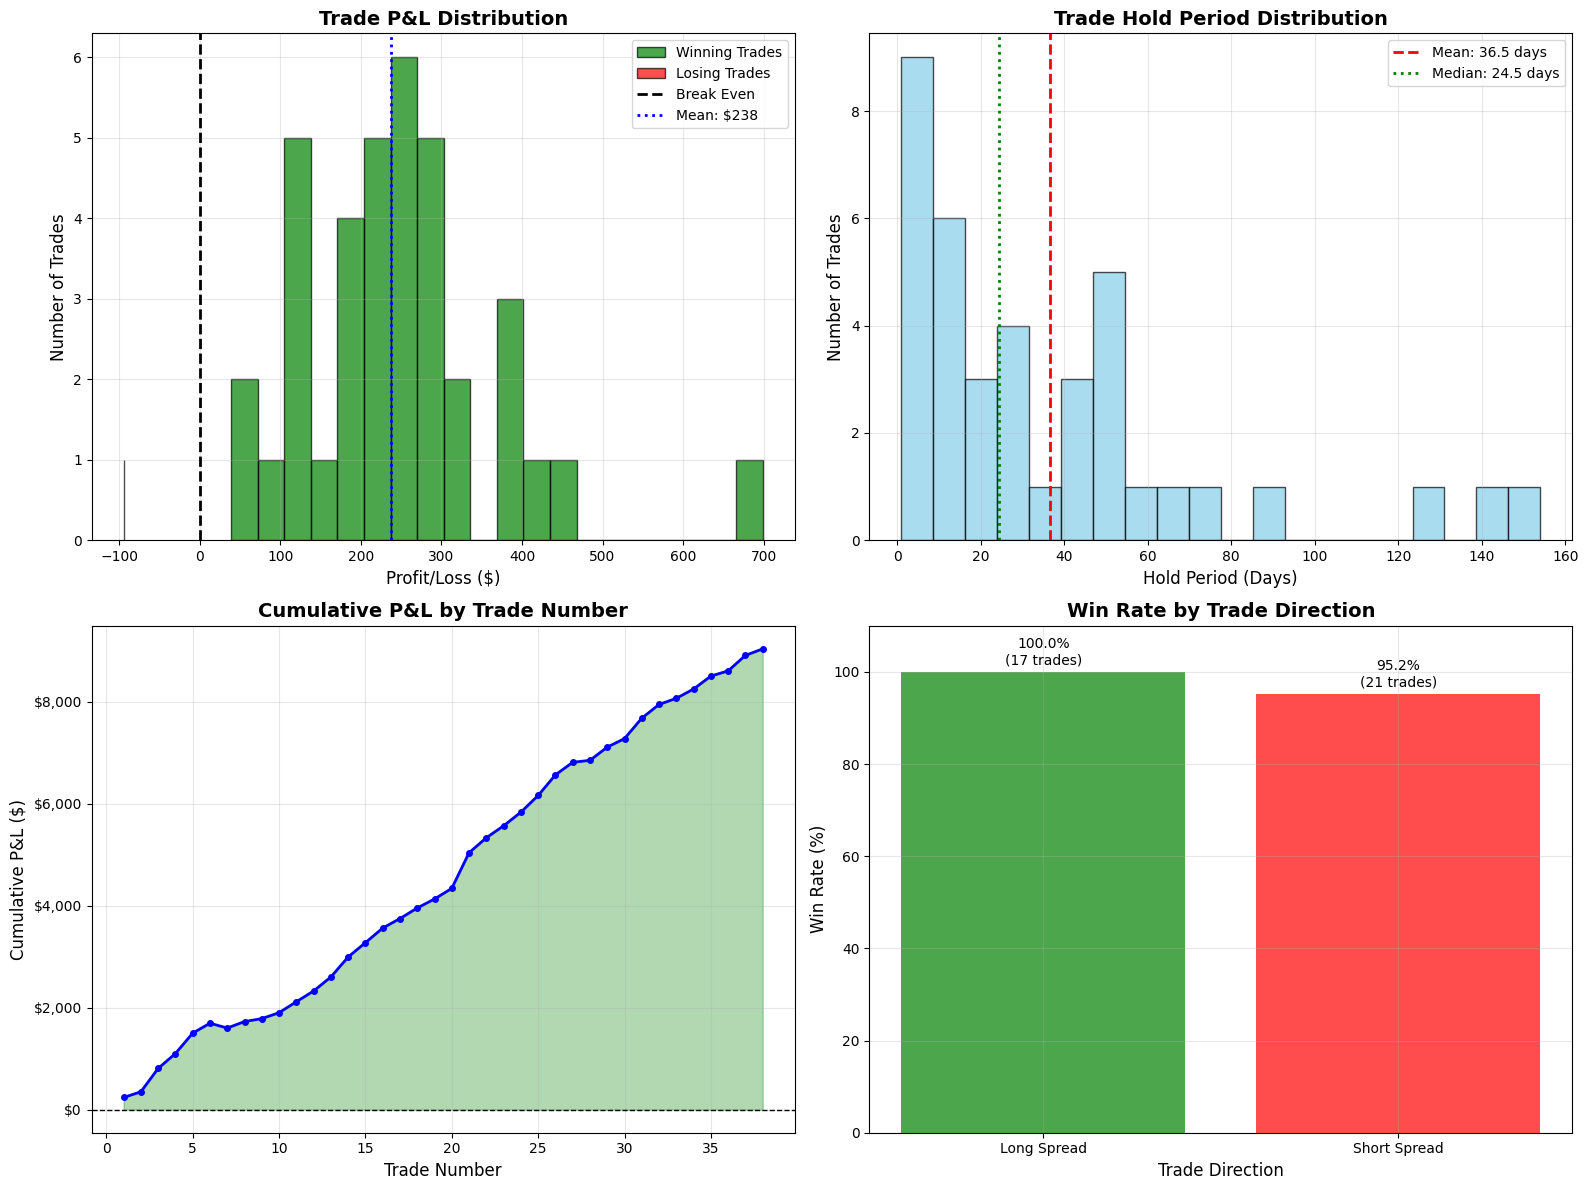

COMPREHENSIVE PERFORMANCE STATISTICS:
Signal Generation:
  Total signals generated: 78
  Entry signals: 39
  Exit signals: 39
  Long entries: 18
  Short entries: 21

Trading Performance:
  Completed trades: 38
  Win rate: 97.4%
  Total P&L: $9,033
  Average trade P&L: $238
  Average hold period: 36.5 days

Advanced Metrics:
  Profit factor: 96.75
  Max drawdown: -5.57%
  Sharpe ratio: 1.05
  Largest win: $699
  Largest loss: $-94
  Average win: $247
  Average loss: $-94

Z-Score Analysis:
  Average entry Z-score: 0.260
  Average exit Z-score: -0.056


In [590]:
def visualize_signal_performance(trading_signals, close_prices, zscore_results, performance_results):
    """
    Create comprehensive signal performance visualization and statistics.
    
    Parameters:
    -----------
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    close_prices : pd.DataFrame
        DataFrame with close prices for SYMBOL1 and SYMBOL2
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
    performance_results : dict
        Results from analyze_signal_performance function
        
    Returns:
    --------
    dict
        Dictionary containing performance visualization results
    """
    print("CREATING SIGNAL PERFORMANCE VISUALIZATION")
    print("=" * 80)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Trade P&L distribution
    ax1 = axes[0, 0]
    if performance_results and 'trades_df' in performance_results:
        trades_df = performance_results['trades_df']
        if not trades_df.empty:
            pnl = trades_df['pnl']
            win_trades = pnl > 0
            lose_trades = pnl <= 0
            
            ax1.hist(pnl[win_trades], bins=20, alpha=0.7, color='green', label='Winning Trades', edgecolor='black')
            ax1.hist(pnl[lose_trades], bins=20, alpha=0.7, color='red', label='Losing Trades', edgecolor='black')
            ax1.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Break Even')
            ax1.axvline(x=pnl.mean(), color='blue', linestyle=':', linewidth=2, label=f'Mean: ${pnl.mean():.0f}')
            
            ax1.set_title('Trade P&L Distribution', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Profit/Loss ($)', fontsize=12)
            ax1.set_ylabel('Number of Trades', fontsize=12)
            ax1.legend()
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No completed trades found', ha='center', va='center', 
                    transform=ax1.transAxes, fontsize=14)
            ax1.set_title('Trade P&L Distribution', fontsize=14, fontweight='bold')
    
    # Plot 2: Hold period distribution
    ax2 = axes[0, 1]
    if performance_results and 'trades_df' in performance_results:
        trades_df = performance_results['trades_df']
        if not trades_df.empty:
            hold_periods = trades_df['hold_period']
            ax2.hist(hold_periods, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            ax2.axvline(x=hold_periods.mean(), color='red', linestyle='--', linewidth=2, 
                       label=f'Mean: {hold_periods.mean():.1f} days')
            ax2.axvline(x=hold_periods.median(), color='green', linestyle=':', linewidth=2, 
                       label=f'Median: {hold_periods.median():.1f} days')
            
            ax2.set_title('Trade Hold Period Distribution', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Hold Period (Days)', fontsize=12)
            ax2.set_ylabel('Number of Trades', fontsize=12)
            ax2.legend()
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No completed trades found', ha='center', va='center', 
                    transform=ax2.transAxes, fontsize=14)
            ax2.set_title('Trade Hold Period Distribution', fontsize=14, fontweight='bold')
    
    # Plot 3: Cumulative P&L
    ax3 = axes[1, 0]
    if performance_results and 'trades_df' in performance_results:
        trades_df = performance_results['trades_df']
        if not trades_df.empty:
            # Sort trades by exit date
            trades_sorted = trades_df.sort_values('exit_date')
            cumulative_pnl = trades_sorted['pnl'].cumsum()
            
            ax3.plot(range(1, len(cumulative_pnl) + 1), cumulative_pnl, 
                    linewidth=2, color='blue', marker='o', markersize=4)
            ax3.axhline(y=0, color='black', linestyle='--', linewidth=1)
            ax3.fill_between(range(1, len(cumulative_pnl) + 1), 0, cumulative_pnl, 
                           alpha=0.3, color='green' if cumulative_pnl.iloc[-1] > 0 else 'red')
            
            ax3.set_title('Cumulative P&L by Trade Number', fontsize=14, fontweight='bold')
            ax3.set_xlabel('Trade Number', fontsize=12)
            ax3.set_ylabel('Cumulative P&L ($)', fontsize=12)
            ax3.grid(True, alpha=0.3)
            
            # Add format for y-axis
            ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        else:
            ax3.text(0.5, 0.5, 'No completed trades found', ha='center', va='center', 
                    transform=ax3.transAxes, fontsize=14)
            ax3.set_title('Cumulative P&L by Trade Number', fontsize=14, fontweight='bold')
    
    # Plot 4: Win rate by trade direction
    ax4 = axes[1, 1]
    if performance_results and 'trades_df' in performance_results:
        trades_df = performance_results['trades_df']
        if not trades_df.empty:
            # Calculate win rates by direction
            directions = ['long_spread', 'short_spread']
            win_rates = []
            trade_counts = []
            
            for direction in directions:
                direction_trades = trades_df[trades_df['direction'] == direction]
                if len(direction_trades) > 0:
                    win_rate = (direction_trades['pnl'] > 0).sum() / len(direction_trades) * 100
                    win_rates.append(win_rate)
                    trade_counts.append(len(direction_trades))
                else:
                    win_rates.append(0)
                    trade_counts.append(0)
            
            # Create bar chart
            x_pos = np.arange(len(directions))
            bars = ax4.bar(x_pos, win_rates, alpha=0.7, color=['green', 'red'])
            
            # Add value labels on bars
            for i, (bar, count) in enumerate(zip(bars, trade_counts)):
                height = bar.get_height()
                ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{win_rates[i]:.1f}%\n({count} trades)',
                        ha='center', va='bottom', fontsize=10)
            
            ax4.set_title('Win Rate by Trade Direction', fontsize=14, fontweight='bold')
            ax4.set_xlabel('Trade Direction', fontsize=12)
            ax4.set_ylabel('Win Rate (%)', fontsize=12)
            ax4.set_xticks(x_pos)
            ax4.set_xticklabels(['Long Spread', 'Short Spread'])
            ax4.set_ylim(0, max(win_rates) + 10 if win_rates else 100)
            ax4.grid(True, alpha=0.3)
        else:
            ax4.text(0.5, 0.5, 'No completed trades found', ha='center', va='center', 
                    transform=ax4.transAxes, fontsize=14)
            ax4.set_title('Win Rate by Trade Direction', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate comprehensive performance statistics
    perf_stats = calculate_comprehensive_performance_stats(trading_signals, close_prices, 
                                                         zscore_results, performance_results)
    
    return perf_stats

def calculate_comprehensive_performance_stats(trading_signals, close_prices, zscore_results, performance_results):
    """
    Calculate comprehensive performance statistics.
    
    Parameters:
    -----------
    trading_signals : pd.DataFrame
        Trading signals from generate_trading_signals function
    close_prices : pd.DataFrame
        DataFrame with close prices for GOOG and GOOGL
    zscore_results : pd.DataFrame
        Results from calculate_rolling_zscore function
    performance_results : dict
        Results from analyze_signal_performance function
        
    Returns:
    --------
    dict
        Dictionary containing comprehensive performance statistics
    """
    stats_dict = {}
    
    # Signal generation statistics
    if not trading_signals.empty:
        # Count entries and exits based on position changes
        position_changes = trading_signals['position'].diff()
        entry_signals_mask = (trading_signals['position'] != 0) & (position_changes != 0)
        exit_signals_mask = (trading_signals['position'] == 0) & (position_changes != 0)
        
        entry_positions = trading_signals.loc[entry_signals_mask, 'position']
        
        stats_dict.update({
            'total_signals_generated': entry_signals_mask.sum() + exit_signals_mask.sum(),
            'entry_signals_generated': entry_signals_mask.sum(),
            'exit_signals_generated': exit_signals_mask.sum(),
            'long_entries_generated': (entry_positions == 1).sum(),
            'short_entries_generated': (entry_positions == -1).sum()
        })
    
    # Performance statistics
    if performance_results:
        stats_dict.update({
            'total_completed_trades': performance_results.get('total_trades', 0),
            'win_rate': performance_results.get('win_rate', 0),
            'total_pnl': performance_results.get('total_pnl', 0),
            'avg_trade_pnl': performance_results.get('avg_trade_pnl', 0),
            'avg_hold_period': performance_results.get('avg_hold_period', 0)
        })
        
        # Calculate additional metrics
        if 'trades_df' in performance_results and not performance_results['trades_df'].empty:
            trades_df = performance_results['trades_df']
            pnl = trades_df['pnl']
            
            # Profit factor
            gross_profit = pnl[pnl > 0].sum()
            gross_loss = abs(pnl[pnl < 0].sum())
            profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
            
            # Maximum drawdown
            cumulative_pnl = pnl.cumsum()
            running_max = cumulative_pnl.expanding().max()
            drawdown = (cumulative_pnl - running_max) / running_max
            max_drawdown = drawdown.min()
            
            # Sharpe ratio (approximate)
            valid_data = performance_results.get('valid_data')
            
            if valid_data is not None and not valid_data.empty:
                strategy_returns = valid_data['total_daily_pnl'] / 100000 
                sharpe_ratio = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252) if strategy_returns.std() > 0 else 0
            else:
                sharpe_ratio = 0 
                
            stats_dict.update({
                'gross_profit': gross_profit,
                'gross_loss': gross_loss,
                'profit_factor': profit_factor,
                'max_drawdown': max_drawdown,
                'sharpe_ratio': sharpe_ratio,
                'largest_win': pnl.max(),
                'largest_loss': pnl.min(),
                'avg_win': pnl[pnl > 0].mean() if (pnl > 0).any() else 0,
                'avg_loss': pnl[pnl < 0].mean() if (pnl < 0).any() else 0
            })
    
    # Z-score statistics at signal points - FIXED INDEXING
    if not trading_signals.empty and 'zscore' in trading_signals.columns:
        # Entry Z-scores - use zscore from trading_signals to avoid index mismatch
        entry_signals_mask = (trading_signals['position'] != 0) & (trading_signals['position'].diff() != 0)
        if entry_signals_mask.any():
            entry_zscores = trading_signals.loc[entry_signals_mask, 'zscore']
            stats_dict.update({
                'avg_entry_zscore': entry_zscores.mean(),
                'max_entry_zscore': entry_zscores.max(),
                'min_entry_zscore': entry_zscores.min()
            })
        
        # Exit Z-scores - use zscore from trading_signals
        exit_signals_mask = (trading_signals['position'] == 0) & (trading_signals['position'].diff() != 0)
        if exit_signals_mask.any():
            exit_zscores = trading_signals.loc[exit_signals_mask, 'zscore']
            stats_dict.update({
                'avg_exit_zscore': exit_zscores.mean(),
                'max_exit_zscore': exit_zscores.max(),
                'min_exit_zscore': exit_zscores.min()
            })
    
    return stats_dict

# Create signal performance visualization
if 'trading_signals' in locals() and 'close_prices' in locals() and 'zscore_results' in locals():
    
    # Get performance results if available
    perf_results = performance_results if 'performance_results' in locals() else {}
    
    perf_viz_results = visualize_signal_performance(trading_signals, close_prices, zscore_results, perf_results)
    
    # Display comprehensive performance statistics
    print("COMPREHENSIVE PERFORMANCE STATISTICS:")
    print("=" * 80)
    
    print("Signal Generation:")
    print(f"  Total signals generated: {perf_viz_results.get('total_signals_generated', 0)}")
    print(f"  Entry signals: {perf_viz_results.get('entry_signals_generated', 0)}")
    print(f"  Exit signals: {perf_viz_results.get('exit_signals_generated', 0)}")
    print(f"  Long entries: {perf_viz_results.get('long_entries_generated', 0)}")
    print(f"  Short entries: {perf_viz_results.get('short_entries_generated', 0)}")
    
    print("\nTrading Performance:")
    print(f"  Completed trades: {perf_viz_results.get('total_completed_trades', 0)}")
    print(f"  Win rate: {perf_viz_results.get('win_rate', 0):.1f}%")
    print(f"  Total P&L: ${perf_viz_results.get('total_pnl', 0):,.0f}")
    print(f"  Average trade P&L: ${perf_viz_results.get('avg_trade_pnl', 0):,.0f}")
    print(f"  Average hold period: {perf_viz_results.get('avg_hold_period', 0):.1f} days")
    
    if perf_viz_results.get('profit_factor', 0) > 0:
        print(f"\nAdvanced Metrics:")
        print(f"  Profit factor: {perf_viz_results.get('profit_factor', 0):.2f}")
        print(f"  Max drawdown: {perf_viz_results.get('max_drawdown', 0):.2%}")
        print(f"  Sharpe ratio: {perf_viz_results.get('sharpe_ratio', 0):.2f}")
        print(f"  Largest win: ${perf_viz_results.get('largest_win', 0):,.0f}")
        print(f"  Largest loss: ${perf_viz_results.get('largest_loss', 0):,.0f}")
        print(f"  Average win: ${perf_viz_results.get('avg_win', 0):,.0f}")
        print(f"  Average loss: ${perf_viz_results.get('avg_loss', 0):,.0f}")
    
    if perf_viz_results.get('avg_entry_zscore') is not None:
        print(f"\nZ-Score Analysis:")
        print(f"  Average entry Z-score: {perf_viz_results.get('avg_entry_zscore', 0):.3f}")
        print(f"  Average exit Z-score: {perf_viz_results.get('avg_exit_zscore', 0):.3f}")
    
else:
    print("❌ Required data not available for performance visualization")
    print("Please run the previous cells to generate trading signals and performance data first.")

## 4. Backtesting Architecture Evaluation

### 4.1 Test with Existing ScheduleBasedEngine

Now we'll test our cointegration pairs trading strategy using the existing TiPortfolio infrastructure. This involves:

1. **Creating a custom allocation strategy** that implements our cointegration signal logic
2. **Testing with ScheduleBasedEngine** to evaluate if schedule-based approach works for signal trading
3. **Identifying limitations** and requirements for event-driven approach

The ScheduleBasedEngine is designed for periodic rebalancing (monthly, quarterly, etc.), but our pairs trading strategy is signal-driven (based on Z-score thresholds). We'll need to adapt our approach to work within this constraint.

In [591]:
# Create a custom allocation strategy for cointegration pairs trading
from typing import Protocol, Any

class CointegrationPairsStrategy:
    """
    Custom allocation strategy for cointegration-based pairs trading.
    
    This strategy implements the signal logic based on Z-score thresholds
    but adapts it to work with the schedule-based rebalancing approach.
    """
    
    def __init__(self, symbols: list[str], hedge_ratio: float, 
                 z_entry_threshold: float = 2.0, z_exit_threshold: float = 0.0,
                 lookback_window: int = 252):
        """
        Initialize the cointegration pairs trading strategy.
        
        Parameters:
        -----------
        symbols : list[str]
            Trading symbols (should be exactly 2 for pairs trading)
        hedge_ratio : float
            Hedge ratio calculated from Johansen cointegration test
        z_entry_threshold : float, default 2.0
            Z-score threshold for entering positions
        z_exit_threshold : float, default 0.0
            Z-score threshold for exiting positions
        lookback_window : int, default 252
            Rolling window for calculating Z-scores
        """
        if len(symbols) != 2:
            raise ValueError("CointegrationPairsStrategy requires exactly 2 symbols")
            
        self.symbols = symbols
        self.symbol1, self.symbol2 = symbols
        self.hedge_ratio = hedge_ratio
        self.z_entry_threshold = z_entry_threshold
        self.z_exit_threshold = z_exit_threshold
        self.lookback_window = lookback_window
        
        # Store historical data for Z-score calculations
        self.price_history = pd.DataFrame()
        self.current_position = 0  # -1: short spread, 0: neutral, 1: long spread
        
    def get_symbols(self) -> list[str]:
        """Return the list of symbols this strategy trades."""
        return self.symbols
    
    def get_target_weights(self, date: pd.Timestamp, total_equity: float, 
                         positions_dollars: dict[str, float], 
                         prices_row: pd.Series, **context: Any) -> dict[str, float]:
        """
        Calculate target weights based on cointegration signals.
        
        This method adapts our signal-driven strategy to work with schedule-based rebalancing.
        Since ScheduleBasedEngine calls this method on rebalance dates, we check if
        our Z-score conditions are met and adjust positions accordingly.
        
        Parameters:
        -----------
        date : pd.Timestamp
            Current date for the rebalancing decision
        total_equity : float
            Total portfolio equity
        positions_dollars : dict[str, float]
            Current dollar positions in each symbol
        prices_row : pd.Series
            Current prices for all symbols
        **context : Any
            Additional context (not used in this strategy)
            
        Returns:
        --------
        dict[str, float]
            Target weights for each symbol (sum to 1.0 or 0.0 for neutral)
        """
        try:
            # Update price history
            self._update_price_history(date, prices_row)
            
            # Calculate Z-score if we have enough data
            if len(self.price_history) < self.lookback_window:
                print(f"Date {date}: Insufficient data for Z-score calculation ({len(self.price_history)} < {self.lookback_window})")
                return {symbol: 0.0 for symbol in self.symbols}
            
            # Calculate current spread and Z-score
            current_spread = self._calculate_spread(prices_row)
            z_score = self._calculate_z_score(current_spread)
            
            # Determine signal based on Z-score
            signal = self._determine_signal(z_score)
            
            # Calculate position sizes based on signal
            if signal == 0:  # Neutral - no position
                target_weights = {symbol: 0.0 for symbol in self.symbols}
                position_action = "CLOSE POSITION"
            elif signal == 1:  # Long spread (long symbol1, short symbol2)
                # Allocate 50% to each side when in position
                target_weights = {
                    self.symbol1: 0.5,
                    self.symbol2: -0.5
                }
                position_action = "LONG SPREAD"
            else:  # Short spread (short symbol1, long symbol2)
                target_weights = {
                    self.symbol1: -0.5,
                    self.symbol2: 0.5
                }
                position_action = "SHORT SPREAD"
            
            # Log the decision
            print(f"Date {date}: Z-Score={z_score:.3f}, Signal={signal}, Action={position_action}")
            
            return target_weights
            
        except Exception as e:
            print(f"Error in get_target_weights for date {date}: {e}")
            return {symbol: 0.0 for symbol in self.symbols}
    
    def _update_price_history(self, date: pd.Timestamp, prices_row: pd.Series):
        """Update the price history with current prices."""
        # Get log prices
        log_prices = np.log(prices_row[self.symbols])
        self.price_history = pd.concat([self.price_history, log_prices.to_frame().T], ignore_index=False)
        
        # Keep only the most recent data points
        if len(self.price_history) > self.lookback_window * 2:
            self.price_history = self.price_history.tail(self.lookback_window * 2)
    
    def _calculate_spread(self, prices_row: pd.Series) -> float:
        """Calculate the current spread using hedge ratio."""
        log_symbol1 = np.log(prices_row[self.symbol1])
        log_symbol2 = np.log(prices_row[self.symbol2])
        return log_symbol1 - self.hedge_ratio * log_symbol2
    
    def _calculate_z_score(self, current_spread: float) -> float:
        """Calculate Z-score for current spread."""
        if len(self.price_history) < self.lookback_window:
            return 0.0
        
        # Calculate historical spreads
        historical_log_prices = self.price_history.tail(self.lookback_window)
        historical_spreads = (historical_log_prices.iloc[:, 0] - 
                           self.hedge_ratio * historical_log_prices.iloc[:, 1])
        
        # Calculate rolling statistics
        spread_mean = historical_spreads.mean()
        spread_std = historical_spreads.std()
        
        if spread_std == 0:
            return 0.0
        
        # Calculate Z-score
        z_score = (current_spread - spread_mean) / spread_std
        return z_score
    
    def _determine_signal(self, z_score: float) -> int:
        """
        Determine trading signal based on Z-score.
        
        Returns:
        --------
        int
            -1: Short spread (short symbol1, long symbol2)
             0: Neutral (no position)
             1: Long spread (long symbol1, short symbol2)
        """
        # Entry signals
        if z_score > self.z_entry_threshold:
            return -1  # Short spread
        elif z_score < -self.z_entry_threshold:
            return 1   # Long spread
        
        # Exit signal - cross zero
        if abs(z_score) < self.z_exit_threshold:
            return 0   # Neutral
        
        # Hold current position
        return self.current_position

print("✅ CointegrationPairsStrategy class defined successfully!")

✅ CointegrationPairsStrategy class defined successfully!


In [592]:
# Test the custom strategy with ScheduleBasedEngine
print("TESTING COINTEGRATION STRATEGY WITH SCHEDULEBASEDENGINE")
print("=" * 80)

# Initialize our custom strategy
try:
    cointegration_strategy = CointegrationPairsStrategy(
        symbols=symbols,
        hedge_ratio=selected_hedge_ratio,
        z_entry_threshold=BASELINE_PARAMS['z_entry_threshold'],
        z_exit_threshold=BASELINE_PARAMS['z_exit_threshold'],
        lookback_window=BASELINE_PARAMS['lookback_window']
    )
    
    print(f"✅ Strategy initialized successfully!")
    print(f"  - Symbols: {symbols}")
    print(f"  - Hedge Ratio: {selected_hedge_ratio:.6f}")
    print(f"  - Z-Entry Threshold: {BASELINE_PARAMS['z_entry_threshold']}")
    print(f"  - Z-Exit Threshold: {BASELINE_PARAMS['z_exit_threshold']}")
    print(f"  - Lookback Window: {BASELINE_PARAMS['lookback_window']}")
    
except Exception as e:
    print(f"❌ Failed to initialize strategy: {e}")
    raise

# Test with different rebalancing schedules to see what works best
test_schedules = [
    ('weekly_friday', 'Weekly rebalancing - may capture signals faster'), 
    ('month_end', 'Monthly rebalancing - standard approach'),
    ('quarter_end', 'Quarterly rebalancing - lower turnover')
]

schedule_results = []

for schedule_name, description in test_schedules:
    print(f"\n{'='*60}")
    print(f"TESTING SCHEDULE: {schedule_name.upper()}")
    print(f"Description: {description}")
    print(f"{'='*60}")
    
    try:
        # Create schedule
        schedule = Schedule(schedule_name)
        
        # Initialize engine with our custom strategy
        engine = ScheduleBasedEngine(
            allocation=cointegration_strategy,
            rebalance=schedule,
            initial_value=TOTAL_CAPITAL
        )
        
        # Run backtest
        print(f"Running backtest with {schedule_name} schedule...")
        result = engine.run(
            symbols=symbols,
            start=start_date,
            end=end_date,
        )
        
        # Calculate metrics
        metrics = compute_metrics(result.equity_curve)
        
        # Store results
        schedule_results.append({
            'schedule': schedule_name,
            'description': description,
            'result': result,
            'metrics': metrics
        })
        
        num_trades = len([r for r in result.rebalance_decisions if getattr(r, 'target_weights', {}) != {s: 0.0 for s in symbols}])

        print(f"✅ Backtest completed for {schedule_name} schedule!")
        print(f"  - Final Equity: ${result.equity_curve.iloc[-1]:,.0f}")
        print(f"  - Total Return: {(result.equity_curve.iloc[-1] / TOTAL_CAPITAL - 1) * 100:.2f}%")
        print(f"  - Sharpe Ratio: {metrics.get('sharpe_ratio', 'N/A'):.3f}")
        print(f"  - Max Drawdown: {metrics.get('max_drawdown', 'N/A'):.2%}")
        print(f"  - Number of Trades: {num_trades}")
        
    except Exception as e:
        print(f"❌ Backtest failed for {schedule_name} schedule: {e}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print("SCHEDULE-BASED BACKTESTING SUMMARY")
print(f"{'='*80}")

# Display comparison of different schedules
if schedule_results:
    print(f"{'Schedule':<12} {'Total Return':<12} {'Sharpe Ratio':<12} {'Max DD':<10} {'Trades':<8}")
    print("-" * 70)
    
    for result in schedule_results:
        metrics = result['metrics']
        total_return = (result['result'].equity_curve.iloc[-1] / TOTAL_CAPITAL - 1) * 100
        sharpe = metrics.get('sharpe_ratio', 0)
        max_dd = metrics.get('max_drawdown', 0)
        num_trades = len([r for r in result['result'].rebalance_decisions 
                        if getattr(r, 'target_weights', {}) != {s: 0.0 for s in symbols}])
        
        print(f"{result['schedule']:<12} {total_return:<11.2f}% {sharpe:<11.3f} {max_dd:<9.2%} {num_trades:<8}")
    
    # Find best performing schedule
    best_schedule = max(schedule_results, key=lambda x: x['metrics'].get('sharpe_ratio', 0))
    print(f"\n🏆 Best Schedule: {best_schedule['schedule']}")
    print(f"   Sharpe Ratio: {best_schedule['metrics'].get('sharpe_ratio', 0):.3f}")
    print(f"   Total Return: {(best_schedule['result'].equity_curve.iloc[-1] / TOTAL_CAPITAL - 1) * 100:.2f}%")
    
else:
    print("❌ No successful backtests completed")

TESTING COINTEGRATION STRATEGY WITH SCHEDULEBASEDENGINE
✅ Strategy initialized successfully!
  - Symbols: ['GOOG', 'GOOGL']
  - Hedge Ratio: 1.013143
  - Z-Entry Threshold: 2.0
  - Z-Exit Threshold: 0.0
  - Lookback Window: 252

TESTING SCHEDULE: WEEKLY_FRIDAY
Description: Weekly rebalancing - may capture signals faster
Running backtest with weekly_friday schedule...
Loading bar data...
Loaded bar data: 0:00:02 

Date 2018-01-02 05:00:00+00:00: Insufficient data for Z-score calculation (1 < 252)
Date 2018-01-05 05:00:00+00:00: Insufficient data for Z-score calculation (2 < 252)
Date 2018-01-12 05:00:00+00:00: Insufficient data for Z-score calculation (3 < 252)
Date 2018-01-19 05:00:00+00:00: Insufficient data for Z-score calculation (4 < 252)
Date 2018-01-26 05:00:00+00:00: Insufficient data for Z-score calculation (5 < 252)
Date 2018-02-02 05:00:00+00:00: Insufficient data for Z-score calculation (6 < 252)
Date 2018-02-09 05:00:00+00:00: Insufficient data for Z-score calculation (7 < 